# Загрузка и анализ данных

Установим необходимые библиотеки

In [1]:
!pip install -q catboost category-encoders optuna scikit-uplift

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 6.2 MB/s eta 0:00:00


Импортируем необходимые библиотеки

In [2]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from category_encoders import CatBoostEncoder

from optuna import create_study
from optuna.distributions import IntDistribution, FloatDistribution
from optuna.samplers import TPESampler

from shap import TreeExplainer, summary_plot

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import sklearn.utils

if not hasattr(sklearn.utils, 'check_matplotlib_support'):
    def check_matplotlib_support(caller_name):
        pass
    sklearn.utils.check_matplotlib_support = check_matplotlib_support

from sklift.metrics import uplift_at_k, uplift_auc_score, qini_auc_score
from sklift.viz import plot_qini_curve, plot_uplift_curve

from catboost import CatBoostClassifier, CatBoostRegressor

import torch
from torch import nn
from torch.nn import functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import clear_output

from abc import ABC, abstractmethod

random_state = 42

Загрузим данные для нашей задачи uplift-моделирования

Также если мы предлагаем клиенту скидку, или акцию BOGO (купи один, второй в подарок), то мы считаем, что делаем клиенту какой-то оффер. В противном же случае считаем, чо оффера не делаем

In [3]:
df = pd.read_csv('Marketing Promotion.csv')
df['offer'] = df['offer'].replace({
    'Buy One Get One': '1',
    'Discount': '1',
    'No Offer': '0'
}).astype(int)
df

,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,1,0
1,6,329.08,1,1,Rural,1,Web,0,0
2,7,180.65,0,1,Surburban,1,Web,1,0
3,9,675.83,1,0,Rural,1,Web,1,0
4,2,45.34,1,0,Urban,0,Web,1,0
...,...,...,...,...,...,...,...,...,...
63995,10,105.54,1,0,Urban,0,Web,1,0
63996,5,38.91,0,1,Urban,1,Phone,1,0
63997,6,29.99,1,0,Urban,1,Phone,1,0
63998,1,552.94,1,0,Surburban,1,Multichannel,1,0


Напишем функцию для отрисовки распределения данных в зависимости от какой-либо из целевых переменных (offer или conversion)

In [4]:
def plot_distributions_with_hue(df, hue, ncols=1, figsize=(12, 6)):
    used = False
    if isinstance(ncols, int):
        ncols = [ncols]
    begin = 0
    for local_ncols in ncols:
        axes = plt.subplots(ncols=local_ncols, figsize=figsize)[1]
        if local_ncols == 1:
            axes = np.array([axes])
        for feature, ax in zip(
            df.columns[begin:(begin + axes.shape[0])],
            axes
        ):
            if df[feature].dtype == 'O':
                sns.countplot(data=df, x=feature, hue=hue)
                for container in ax.containers:
                    ax.bar_label(container)
            else:
                sns.histplot(
                    df[df[hue] == 0][feature],
                    stat='percent',
                    color='blue',
                    label=f'No {hue}',
                    ax=ax
                )
                sns.histplot(
                    df[df[hue] == 1][feature],
                    stat='percent',
                    color='orange',
                    label=hue.capitalize(),
                    ax=ax
                )
            ax.set_title(feature)
            ax.set_xlabel(None)
            ax.legend()
        if not used:
            plt.suptitle(f'Распределение признаков в зависимоти от целевого признака {hue}')
            used = True
        begin += axes.shape[0]
        plt.tight_layout()
    plt.show()

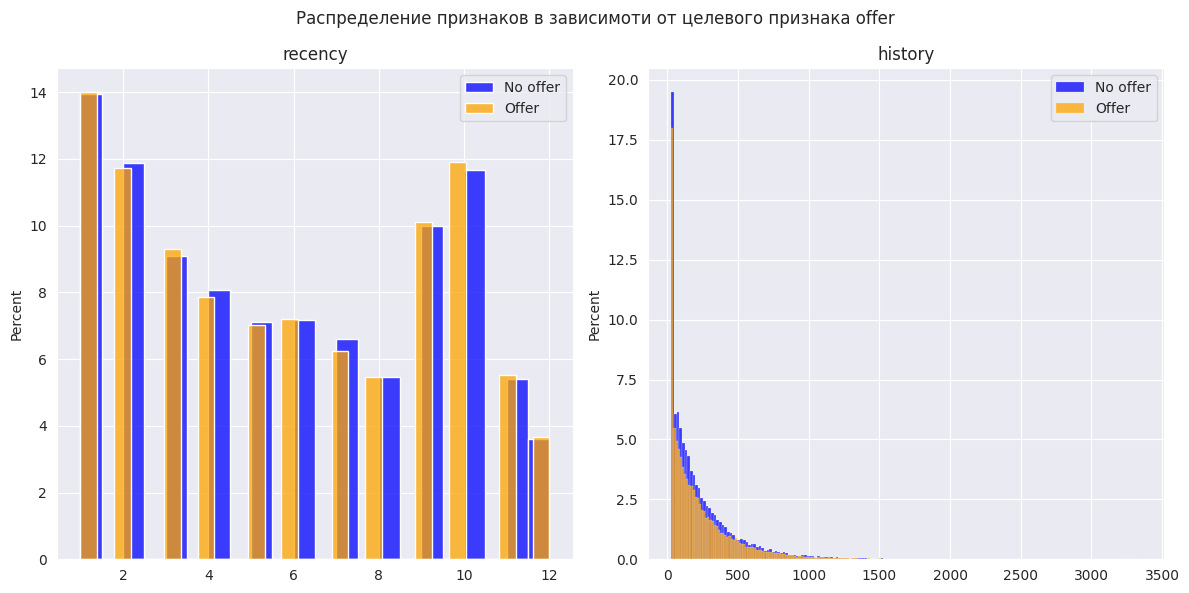

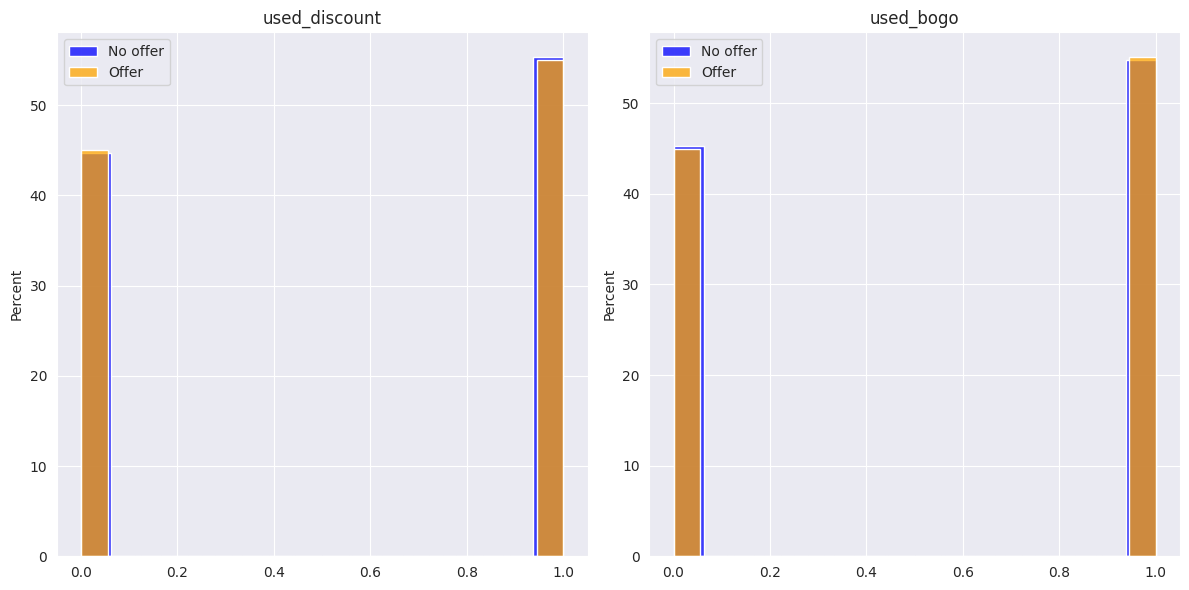

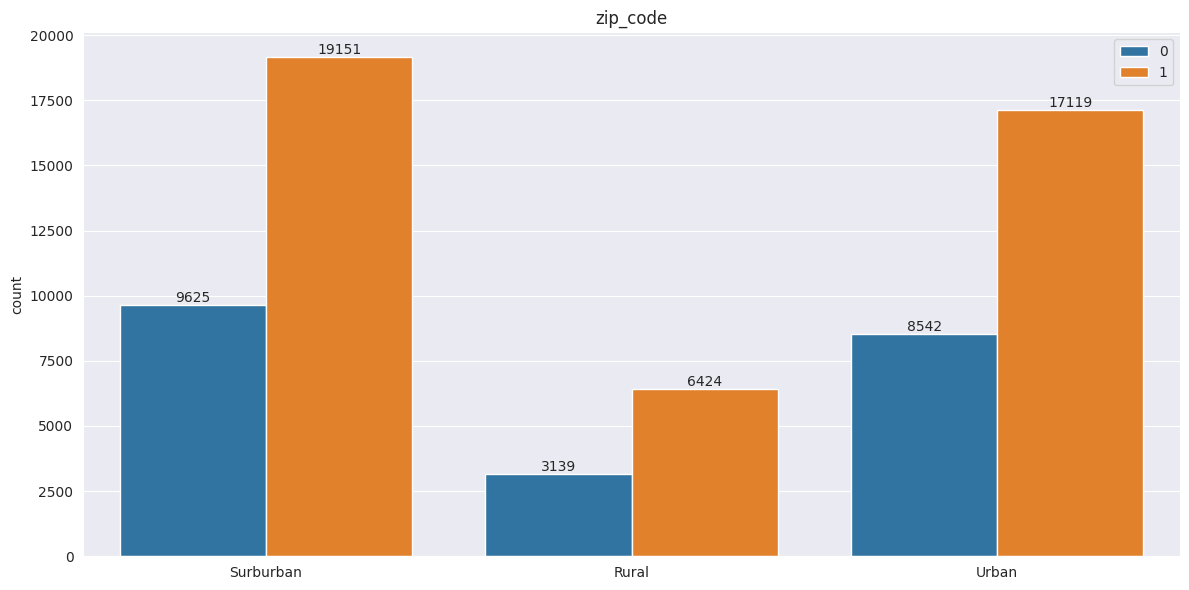

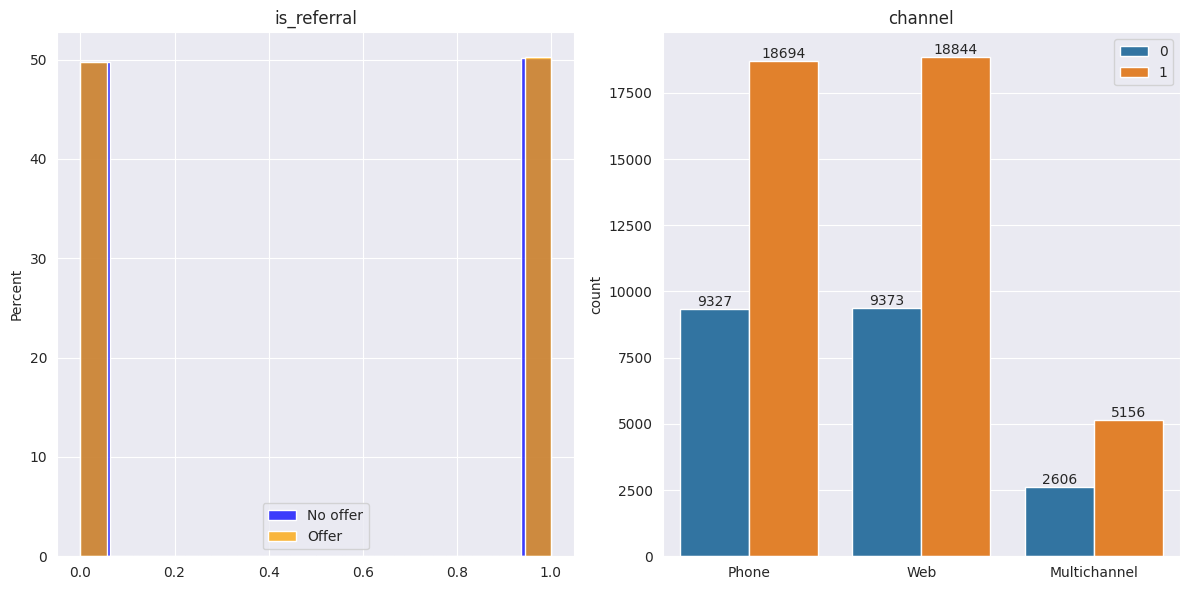

In [5]:
plot_distributions_with_hue(df, 'offer', ncols=[2] * 2 + [1] + [2])

Итак, опишем средний портрет клиента, которому предложили какой-то оффер:
- Он либо совершил последнюю покупку совсем недавно, либо около 10 месяцев назад
- Он суммарно потратил не очень много денег
- Он скорее уже использовал какие-то акции ранее
- В большинстве случаев он горожанин или житель пригорода
- С ним в основном связывались через телефон или по интернету, но не по обоим способам связи сразу

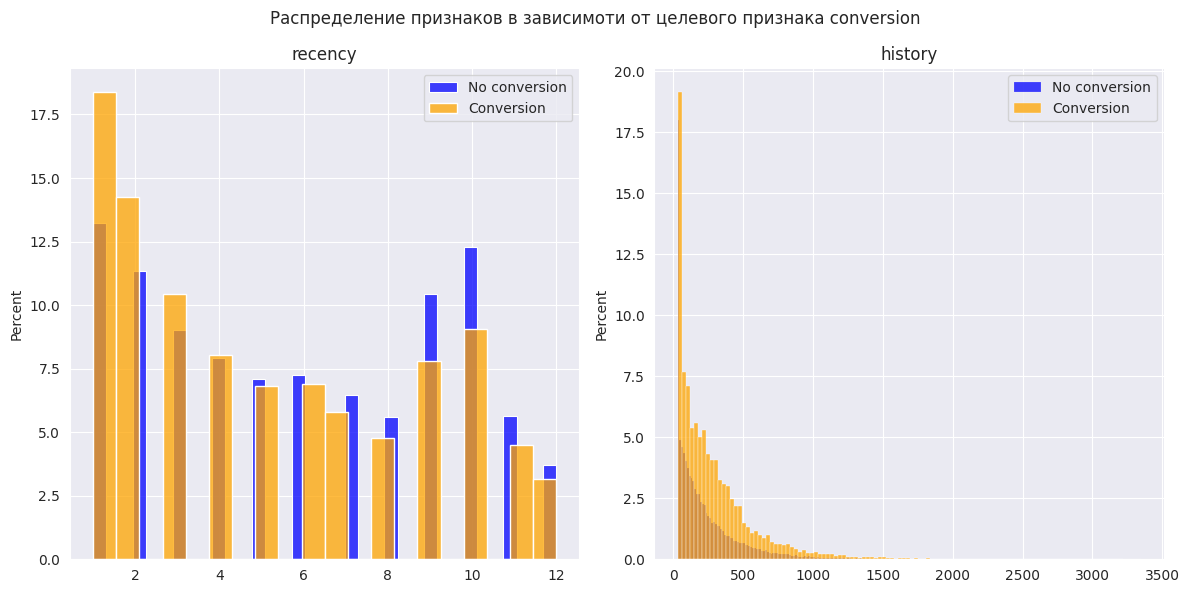

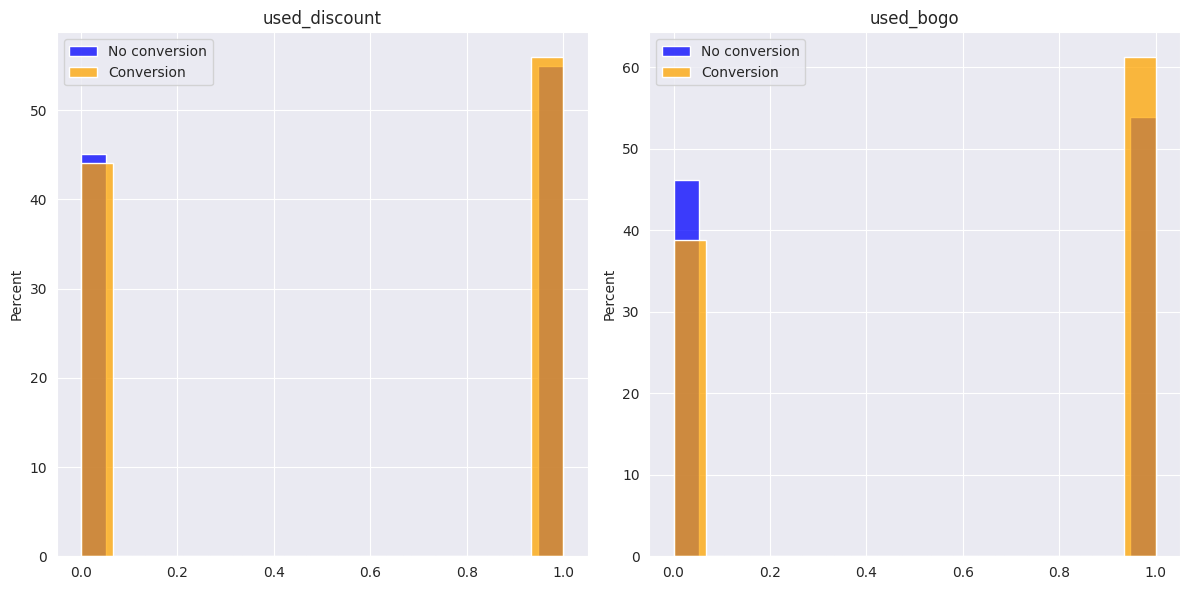

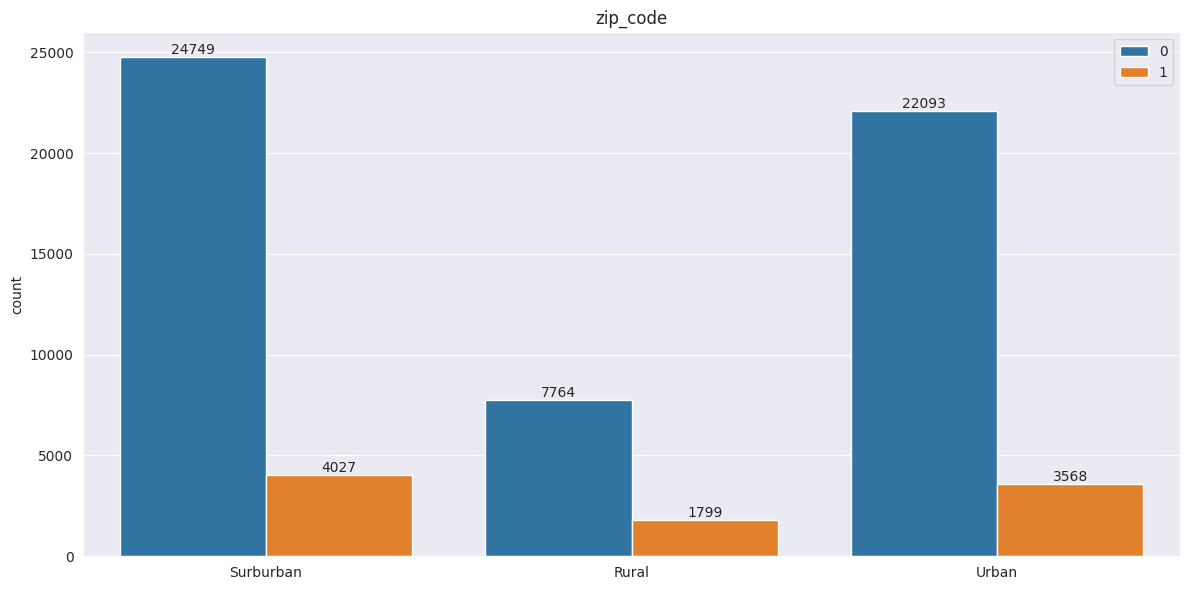

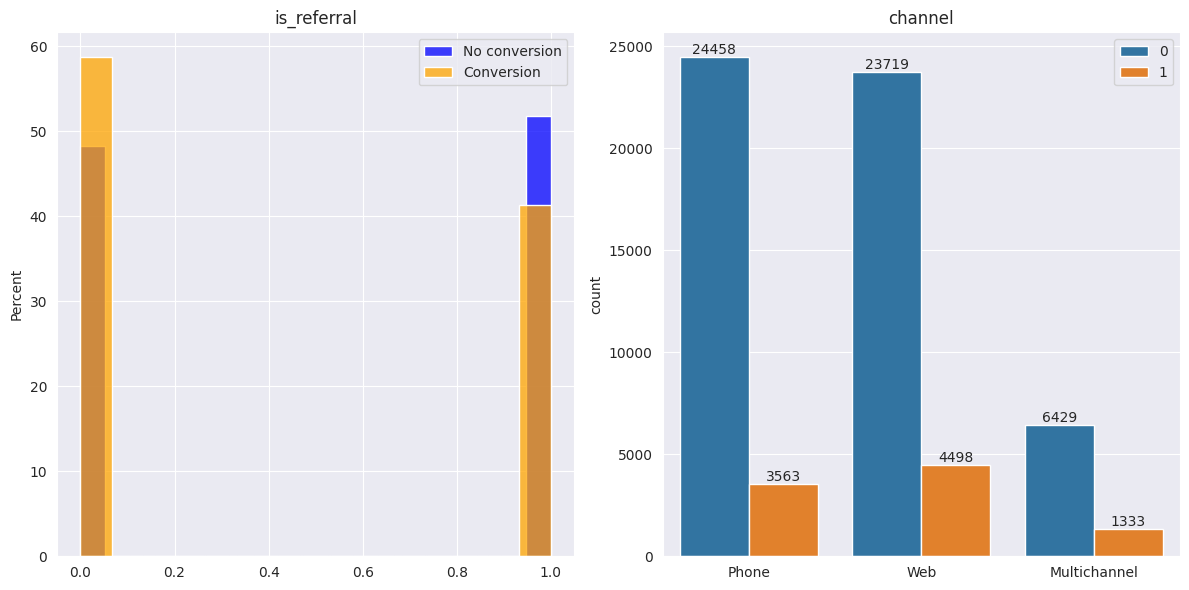

In [6]:
plot_distributions_with_hue(df, 'conversion', ncols=[2] * 2 + [1] + [2])

Теперь опишем средний портрет клиента, который приобрёл товар:
- Он совершил последнюю покупку относительно недавно
- Он суммарно потратил не очень много денег
- Он скорее уже использовал какие-то акции ранее
- В большинстве случаев он горожанин или житель пригорода
- Он нереферальный клиент
- С ним в основном связывались через телефон или по интернету, но не по обоим способам связи сразу

Как видим, средние портреты тех, кто получил оффер и тех, кто ответил приобрёл товар, различаются не сильно

Итак, попробуем сделать следующее - выделим бинарные и категориальные столбцы и создадим признаки, заключающиеся в их попарной конкатенации

In [7]:
binary_columns = [
    column for column in df.columns \
    if column not in ['offer', 'conversion'] and df[column].nunique() == 2
]
categorical_columns = list(df.select_dtypes(include='object').columns)

In [8]:
index = df.columns.get_loc('offer')
new_categorical_columns = list(categorical_columns)
for binary_column in binary_columns:
    for categorical_column in categorical_columns:
        name = binary_column + '_' + categorical_column
        df.insert(
            index,
            name,
            (
                df[binary_column].astype(str) + '_' + \
                df[categorical_column].astype(str)
            )
        )
        new_categorical_columns.append(name)
        index += 1
categorical_columns = new_categorical_columns

Также добавим признак, означающий, пользовался ли клиент сразу двумя типами скидки

In [9]:
df.insert(
    df.columns.get_loc('used_bogo') + 1,
    'used_both',
    df['used_discount'] & df['used_bogo']
)

Далее нам нужно разделить данные таким образом, чтобы оно было стратифицированным по двум столбцам сразу - по offer и по conversion

Дополнительно мы закодируем категориальные столбцы с помощью CatBoost-кодировщика и отнормируем все значения с помощью стандартного скейлера

In [12]:
df['strata'] =  (
    df['conversion'].astype(str) + \
    '_' + df['offer'].astype(str)
)
df_train_and_valid, df_test = train_test_split(
    df,
    stratify=df['strata'],
    test_size=0.25,
    random_state=random_state
)
df_train, df_valid = train_test_split(
    df_train_and_valid,
    stratify=df.loc[df_train_and_valid.index, 'strata'],
    test_size=0.25,
    random_state=random_state
)
X_train, X_valid, X_test = (
    df_train.drop(columns=['conversion', 'offer', 'strata']),
    df_valid.drop(columns=['conversion', 'offer', 'strata']),
    df_test.drop(columns=['conversion', 'offer', 'strata'])
)
treatment_train, treatment_valid, treatment_test = (
    df_train['offer'],
    df_valid['offer'],
    df_test['offer']
)
y_train, y_valid, y_test = (
    df_train['conversion'],
    df_valid['conversion'],
    df_test['conversion']
)

encoder = CatBoostEncoder()
X_train.loc[:, categorical_columns] = encoder.fit_transform(
    X_train[categorical_columns],
    y_train
)
X_valid.loc[:, categorical_columns] = encoder.transform(
    X_valid[categorical_columns]
)
X_test.loc[:, categorical_columns] = encoder.transform(
    X_test[categorical_columns]
)

scaler = StandardScaler()
X_train.loc[:] = scaler.fit_transform(X_train)
X_valid.loc[:] = scaler.transform(X_valid)
X_test.loc[:] = scaler.transform(X_test)

/tmp/ipykernel_3631/182319252.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.78428988  0.63880241  0.92342087 ... -0.78428988  1.49265779
  1.20803933]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:] = scaler.fit_transform(X_train)
/tmp/ipykernel_3631/182319252.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.90250547  0.90250547 -1.10802652 ...  0.90250547 -1.10802652
  0.90250547]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:] = scaler.fit_transform(X_train)
/tmp/ipykernel_3631/182319252.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.10423969 -1.10423969  0.90560049 ... -1.10423969  0.90560049
 -1.10423969]' has dtype incompatible 

Итак, всего существует 4 типа клиентов (см. рис.)
![](https://habrastorage.org/r/w1560/webt/mb/ed/iw/mbediw3l1dh76tk6_0-zgaxz-ss.jpeg)

1) "Не беспокоить" - которые приобретут товар без взаимодейтвия, а так не приобретут (смысла коммуницировать с ним нет, так потеряем клиента)
2) Потерянный - не приобретёт товар ни при каком условии (смысла коммуницировать с ним тоже нет, это просто трата денег и времени)
3) Лояльный - приобретёт товар при любом условии (смысла коммуницировать с ним также нет, ибо клиент итак приобретёт товар)
4) Убеждаемый - которые не приобретут товар без взаимодействия, а с ним приобретут (вот с ними есть смысл коммуницировать, чтобы убедить их приобрести товар)

Смысл задачи uplift-моделирования - найти убеждаемых клиентов, для этого каждому клиенту надо сопоставить некое число, называемое uplift-score и равное разности вероятностей того, что клиент приобретёт товар при условии взаимодействия того, что клиент приобретёт товар при условии отсутствия взаимодействия

Хорошая модель машинного обучения назначает большие скоры именно убеждаемым клиентам, потому как по логике вещей именно для них разность вероятностей должна быть максимальной

# Обучение моделей

С помощью этой функции можно будет посмотреть на распределение значений uplift score

In [13]:
def uplift_histplot(uplift, figsize=(12, 6)):
    ax = plt.subplots(figsize=figsize)[1]
    sns.histplot(uplift, ax=ax)
    ax.set_xlabel('Uplift')
    ax.set_ylabel('Количество')
    plt.show()

Здесь для каждого отдельного признака можно будет увидеть по отсортированным в порядке убывания значениям uplift score, какие именно значения признаков преобладают в зависимости от значения uplift-score

In [14]:
def plot_cumulative_effect(
    df,
    feature,
    q=None,
    figsize=(12, 6),
    current_ax=None
):
    if current_ax is None:
        ax = plt.subplots(figsize=figsize)[1]
    else:
        ax = current_ax
    column = df[feature]
    if q is not None:
        column = pd.qcut(column, q=q)
    for value in column.unique():
        values = (column == value).values.cumsum()
        ax.plot(values / values[-1], label=value)
    ax.legend()
    if current_ax is None:
        plt.show()

Эта функция строит графики с помощью предыдущей для всех признаков

In [15]:
def plot_cumulative_effects(df, uplift, figsize=(12, 6), qs=None, ncols=1):
    df_sorted = df.iloc[np.argsort(uplift)[::-1]]
    used = False
    if isinstance(ncols, int):
        ncols = [ncols]
    begin = 0
    for local_ncols in ncols:
        axes = plt.subplots(ncols=local_ncols, figsize=figsize)[1]
        if local_ncols == 1:
            axes = np.array([axes])
        for feature, ax in zip(
            df_sorted.columns[begin:(begin + axes.shape[0])],
            axes
        ):
            q = None
            if isinstance(qs, dict) and feature in qs:
                q = qs[feature]
            plot_cumulative_effect(df_sorted, feature, q=q, current_ax=ax)
            ax.set_title(feature)
        if not used:
            plt.suptitle('Кумулятивное распределение значений после упорядочивания по uplift')
            used = True
        begin += axes.shape[0]
        plt.tight_layout()
    plt.show()

Эта функция помогает строить на одном графике uplift-AUC- и qini-кривые (о них далее)

In [16]:
def plot_curves(y, uplift, treatment, name, figsize=(20, 6)):
    axes = plt.subplots(ncols=2, figsize=figsize)[1]
    plot_uplift_curve(y, uplift, treatment, ax=axes[0])
    plot_qini_curve(y, uplift, treatment, ax=axes[1])
    plt.suptitle(f'График кривых для модели {name}')
    plt.tight_layout()
    plt.show()

Перейдём к метрикам. Самая простая из них - uplift@k, где мы просто отсекаем топ-k % выборки с наибольшим значением uplift и рассчитываем разность эффектов на целевой и контрольной группах:

$$\large{uplift@k = \mathbb{E}[y@k]_{treatment} - \mathbb{E}[y@k]_{control}}$$

Теоретически метрика принимает значения от -1 (когда в целевой группе нет реакций, а в контрольной все клиенты имеют реакцию) до 1 (здесь уже в целевой группе все откликнулись, а в контрольной не откликнулся никто)

На практике коэффициент принимает значения от 0 до 1, в зависимости от $\large{k}$, датасета и качества модели

Рассчитать эту метрику можно двумя различными способами - либо сначала отсортировать по предсказанному uplift и далее считать разницу двух групп, либо наоборот, изначально отсортировать объекты из контрольной и целевой групп по отдельности, а потом посчитать разницу

Следующая метрика - uplift-кривая, которая строится как функция от количества объектов. В каждой точке кривой можно видеть уже накопленный к этому моменту uplift

$$\large{uplift \ curve(t) = \left(\frac{Y_t^T}{N_t^T}-\frac{Y_t^C}{N_t^C}\right)\left(N_t^T+N_t^C\right),}$$
где:
- $\large{t}$ - накопившееся количество объектов
- $\large{Y_t^T}$ - средний таргет в целевой группе
- $\large{Y_t^С}$ - средний таргет в контрольной группе
- $\large{N_t^T}$ - размер целевой группы
- $\large{N_t^С}$ - размер контрольной группы

График идеальной кривой нарисован краным цветом, реальной - синим, а случайной - чёрным

![](https://habrastorage.org/r/w1560/getpro/habr/upload_files/d2e/a3d/37b/d2ea3d37bb84b9e589fed7fbeb4ec706.png)

Отношение площади между реальной и случайной кривой к площади между идеальной и случайной называется uplift AUC

Есть ещё одна метрика, очень похожая на предыдущую - qini-кривая. Она также кумулятивно рассчитывается сразу для всего набора объектов

Кривая qini показывает, сколько дополнительных целевых действий (например, покупок) мы получим, если провзаимодействуем с топом пользователей, отсортированных моделью

$$\large{qini \ curve(t) = Y_t^T - \frac{Y_t^CN_t^T}{N_t^C}}$$

Физический смысл qini кривой в том, чтобы не давать модели поднимать наверх в ранжировании только целевую группу, штрафуя её за это множителем $\large{\frac{N_t^T}{N_t^C}}$, который уменьшает итоговое значение, если $\large{N_t^T}$ сильно больше, чем $\large{N_t^C}$

Между uplift- и qini-кривыми можно провести очевидную параллель:
$$\large{uplift \ curve(t) = \frac{qini \ curve(t)\left(N_t^T + N_t^C\right)}{N_t^T}}$$

Аналогично с uplift кривой, чем выше кривая над случайной кривой, тем лучше

![](https://habrastorage.org/r/w1560/getpro/habr/upload_files/440/8a6/bac/4408a6bac6cb8759024c743c36b17fff.png)

Ну и по аналогии с предыдущим случаем, qini AUC - это отношение площадей

Итак, напишем функцию для получения метрик для конкретной модели

In [17]:
def get_metrics(y, uplift, treatment, name, metrics=None):
    metrics = pd.concat([
        metrics,
        pd.DataFrame({
            'uplift@10 (overall)': [
                uplift_at_k(y, uplift, treatment, k=0.1, strategy='overall')
            ],
            'uplift@10 (by group)': [
                uplift_at_k(y, uplift, treatment, k=0.1, strategy='by_group')
            ],
            'uplift@30 (overall)': [
                uplift_at_k(y, uplift, treatment, k=0.3, strategy='overall')
            ],
            'uplift@30 (by group)': [
                uplift_at_k(y, uplift, treatment, k=0.3, strategy='by_group')
            ],
            'uplift@50 (overall)': [
                uplift_at_k(y, uplift, treatment, k=0.5, strategy='overall')
            ],
            'uplift@50 (by group)': [
                uplift_at_k(y, uplift, treatment, k=0.5, strategy='by_group')
            ],
            'Uplift AUC': [
                uplift_auc_score(y, uplift, treatment)
            ],
            'QINI AUC': [
                qini_auc_score(y, uplift, treatment)
            ]
        }, index=[name])
    ])
    return metrics

## Классическое обучение

Итак, здесь будет рассмотрена модель CatBoost с трансформацией классов, однако это не та трансформация, которая используется, чтобы сразу получить из модели значение uplift. Здесь всё будет посложнее

Итак, мы знаем 4 типа клиентов, которые существуют в принципе, но в реальности мы наблюдаем следующие 4 типа (см. рис.):

![](https://habrastorage.org/r/w1560/webt/mg/8k/uh/mg8kuhwanl5rprbendzlsiqmvts.jpeg)

1) CN (Control not responder) - клиент из контрольной группы, от которого не было отклика
2) CR (Control not responder) - клиент из контрольной группы, от которого был отклик
3) TN (Target not responder) - клиент из целевой группы, от которого не было отклика
4) TR (Target responder) - клиент из целевой группы, от которого был отклик

А теперь взглянем снова на правую матрицу - и увидим, что чёткого соответствия между левой и правой матрицами нет, ибо каждому типу клиента из левой матрицы могут принадлежать сразу 2 типа клиента из правой:
1) CN - потерянный и убеждаемый
2) CR - "не беспокоить" и лояльный
3) TN - "не беспокоить" и потерянный
4) TR - лояльный и убеждаемый

Итак, как же решить задачу и получить значения uplift score?

Для начала, надо обучать модель на задачу многоклассовой классификации с классами CN, CR, TN и TR

Далее, можно показать, что значение uplift score равняется следующему выражению:
$$\large{uplift \ score = \frac{P\left(TR\right) }{P\left(T\right) } + \frac{P\left(CN\right)}{P\left(C\right)} - \frac{P\left(TN\right)}{P\left(T\right)} - \frac{P\left(CR\right)}{P\left(C\right)},}$$
где:
- $\large{P(T)=P(TN)+P(TR)}$
- $\large{P(C)=P(CN)+P(CR)}$

Это выражение можно упростить следующим образом:
$$\large{uplift \ score = \frac{P\left(TR\right) - P\left(TN\right)}{P\left(TR\right) + P\left(TN\right)} + \frac{P\left(CN\right) - P\left(CR\right)}{P\left(CN\right) + P\left(CR\right)}}$$

### CatBoost

Итак, преобразуем классы

In [18]:
def get_y_uplift(y, treatment):
    y_uplift = pd.Series(index=y.index)
    y_uplift[(y == 0) & (treatment == 0)] = 'CN'
    y_uplift[(y == 0) & (treatment == 1)] = 'CR'
    y_uplift[(y == 1) & (treatment == 0)] = 'TN'
    y_uplift[(y == 1) & (treatment == 1)] = 'TR'
    return y_uplift

In [19]:
y_train_uplift = get_y_uplift(y_train, treatment_train)

/tmp/ipykernel_3631/1805537782.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y_uplift[(y == 0) & (treatment == 0)] = 'CN'


Стратифицировать тренировочную выборку для разбиения на кросс-валидации будем всё также по полю strata (комбинация offer и conversion)

In [20]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
cv_splits = list(skf.split(X_train, df.loc[X_train.index, 'strata']))

Здесь представлены функции по непосредственному нахождению значения uplift-score и подбору оптимальных гиперпараметров для модели CatBoost с помощью фреймворка Optuna

Дополнительно модель CatBoost будет проходить процедуру калибровки, чтобы её вероятности отражали реальное положение дел

In [21]:
def get_uplift(model, X, epsilon=1e-9):
    proba = model.predict_proba(X)
    uplift = (
        (proba[:, 0] - proba[:, 1]) / (proba[:, 0] + proba[:, 1] + epsilon) +
        (proba[:, 3] - proba[:, 2]) / (proba[:, 3] + proba[:, 2] + epsilon)
    )
    return uplift

def objective(trial):
    param_distributions = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1000, step=100),
        'depth': trial.suggest_int('depth', 2, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 1, step=1e-3),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 1, step=1e-3),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50)
    }
    model = CalibratedClassifierCV(
        estimator=CatBoostClassifier(
            **param_distributions,
            random_state=random_state,
            verbose=False
        ),
        cv=cv_splits,
        method='isotonic'
    )
    model.fit(X_train, y_train_uplift)
    uplift = get_uplift(model, X_valid)
    value = qini_auc_score(y_valid, uplift, treatment_valid)
    return value

In [22]:
study = create_study(
    direction='maximize',
    sampler=TPESampler(seed=random_state),
    study_name=f'Оптимизация алгоритма CatBoost'
)
study.optimize(objective, n_trials=25)

[I 2026-08-12 08:15:57,384] A new study created in memory with name: Оптимизация алгоритма CatBoost
[I 2026-08-12 08:21:18,858] Trial 0 finished with value: -0.025187348300150923 and parameters: {'n_estimators': 700, 'depth': 8, 'l2_leaf_reg': 0.735, 'learning_rate': 0.603, 'min_data_in_leaf': 8}. Best is trial 0 with value: -0.025187348300150923.
[I 2026-08-12 08:22:07,426] Trial 1 finished with value: 0.015083555093737908 and parameters: {'n_estimators': 500, 'depth': 2, 'l2_leaf_reg': 0.868, 'learning_rate': 0.605, 'min_data_in_leaf': 36}. Best is trial 1 with value: 0.015083555093737908.
[I 2026-08-12 08:26:23,992] Trial 2 finished with value: -0.016310636290955964 and parameters: {'n_estimators': 500, 'depth': 8, 'l2_leaf_reg': 0.8340000000000001, 'learning_rate': 0.22, 'min_data_in_leaf': 10}. Best is trial 1 with value: 0.015083555093737908.
[I 2026-08-12 08:27:22,662] Trial 3 finished with value: 0.0023880238127826628 and parameters: {'n_estimators': 600, 'depth': 4, 'l2_leaf_r

Итак, обучим модель заново с помощью найденных оптимальных гиперпараметров

In [26]:
%%time
cb_model = CalibratedClassifierCV(
    estimator=CatBoostClassifier(
        **study.best_params,
        random_state=random_state,
        verbose=False
    ),
    cv=cv_splits,
    method='isotonic'
)
cb_model.fit(X_train, y_train_uplift)
cb_model_uplift = get_uplift(cb_model, X_test)

CPU times: user 1min 25s, sys: 1.72 s, total: 1min 27s
Wall time: 1min


Мы будем оценивать важность признаков с помощью такого инструмента, как SHAP. И для этого нужно посчитать shap-значения для каждой модели калибровочного классификатора и усреднить их

In [27]:
%%time
class_names=sorted(y_train_uplift.unique())
shap_values=np.zeros((X_test.shape[0], X_test.shape[1], len(class_names)))
for calibrated_classifier in cb_model.calibrated_classifiers_:
    explainer = TreeExplainer(calibrated_classifier.estimator)
    shap_values += explainer.shap_values(X_test)
shap_values /= len(cb_model.calibrated_classifiers_)

CPU times: user 16 s, sys: 272 ms, total: 16.3 s
Wall time: 12.6 s


Построим график важности признаков

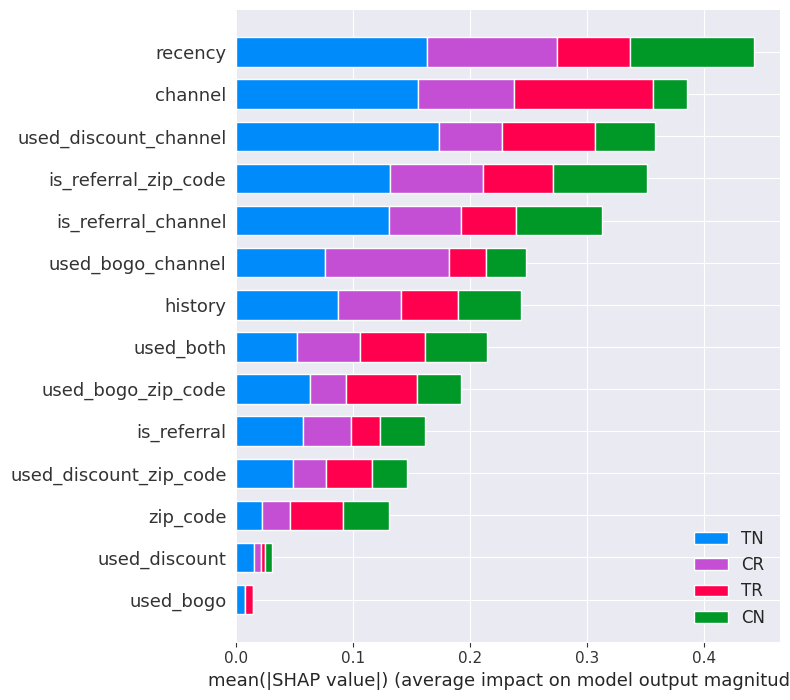

In [28]:
summary_plot(
    shap_values,
    features=X_test,
    feature_names=X_test.columns,
    plot_type='bar',
    class_names=class_names,
    max_display=X_test.shape[1]
)

Получим значения метрик для модели

In [29]:
metrics = get_metrics(
    y_test,
    cb_model_uplift,
    treatment_test,
    cb_model.__class__.__name__,
)

Построим распределение значений uplift score

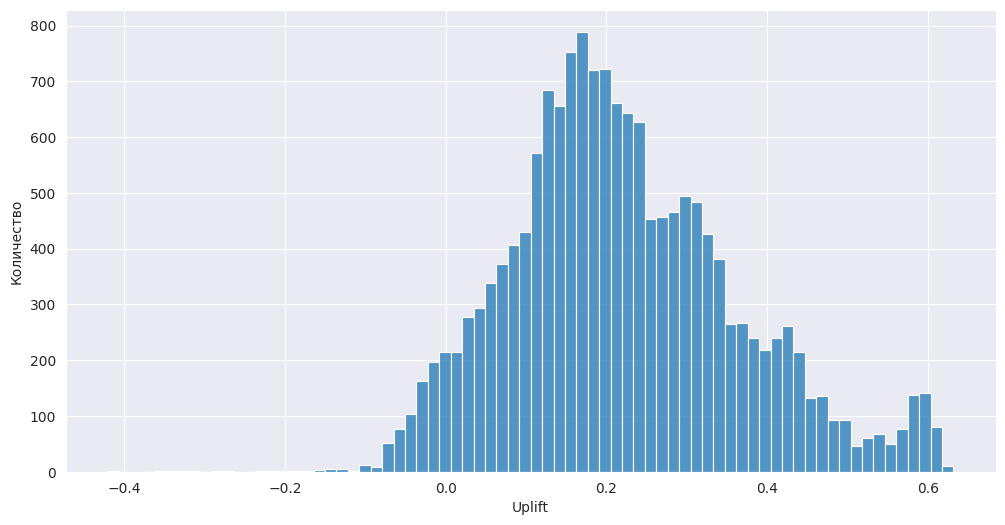

In [30]:
uplift_histplot(cb_model_uplift)

Видим, что разброс достаточно большой, и в основном наблюдается по мнеию модели положительный эффект от взаимодействия с клиентами

Понаблюдаем за кумулятивными эффектами признаков в зависимости от значения uplift score

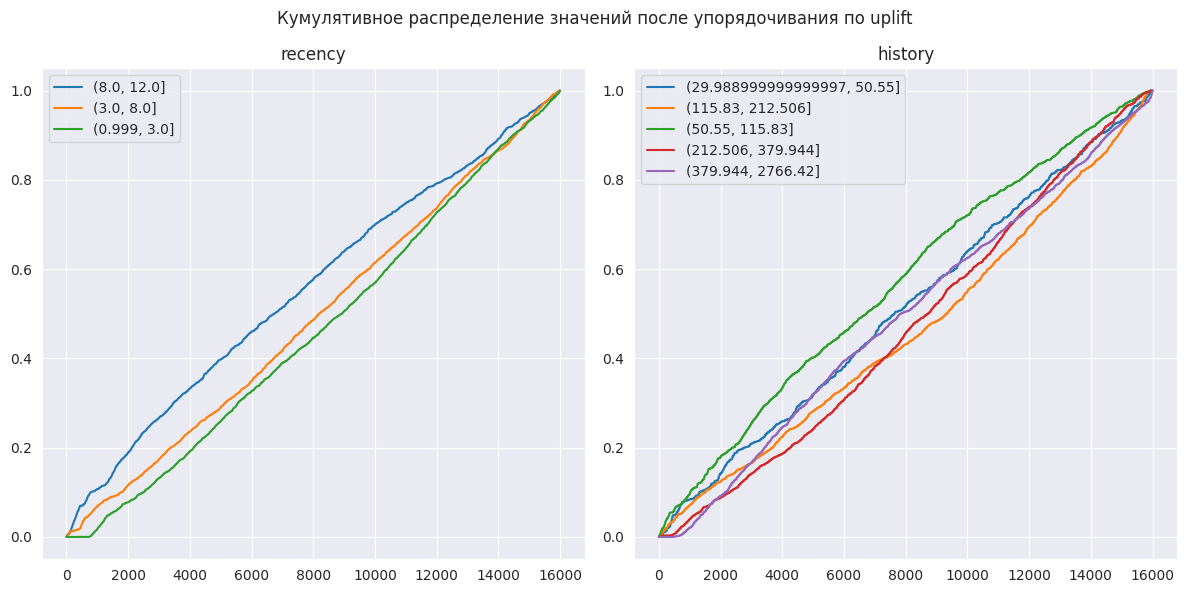

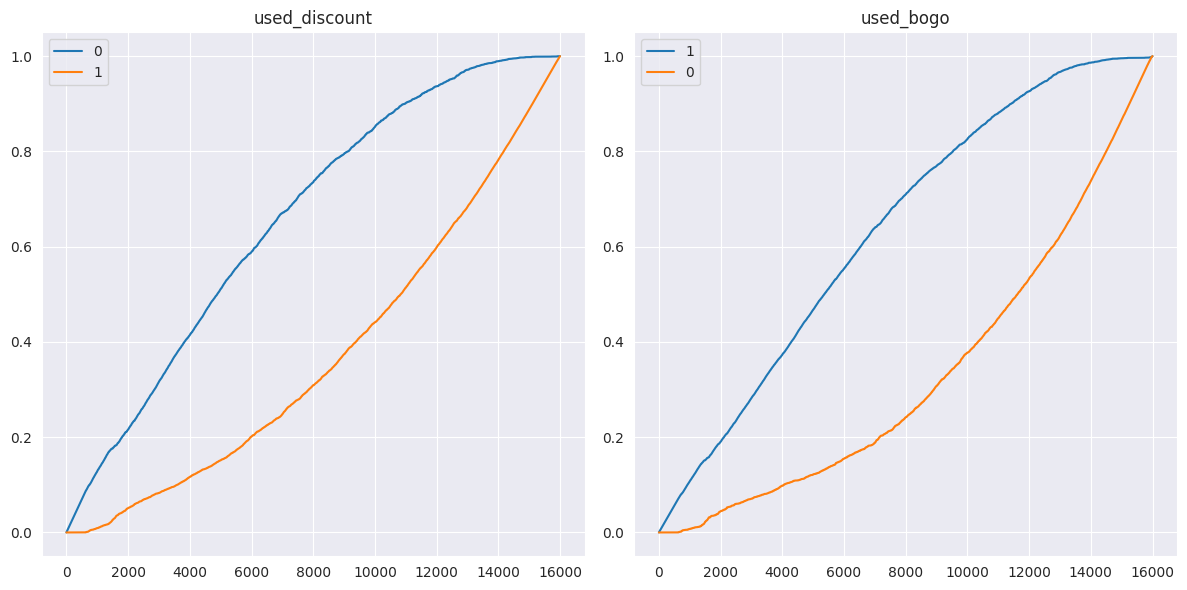

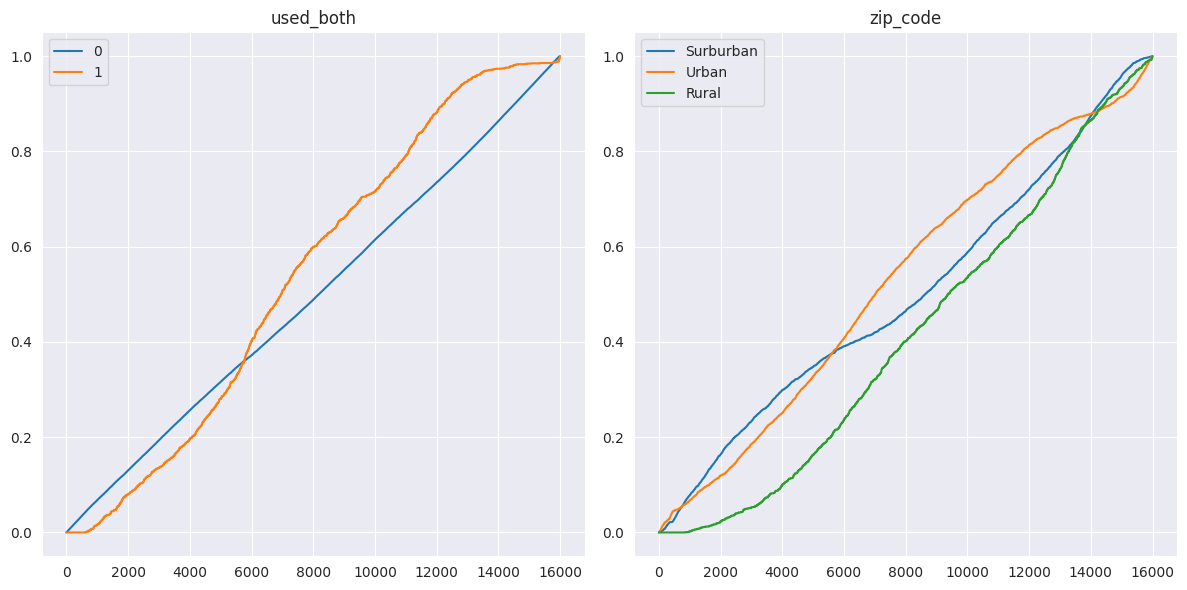

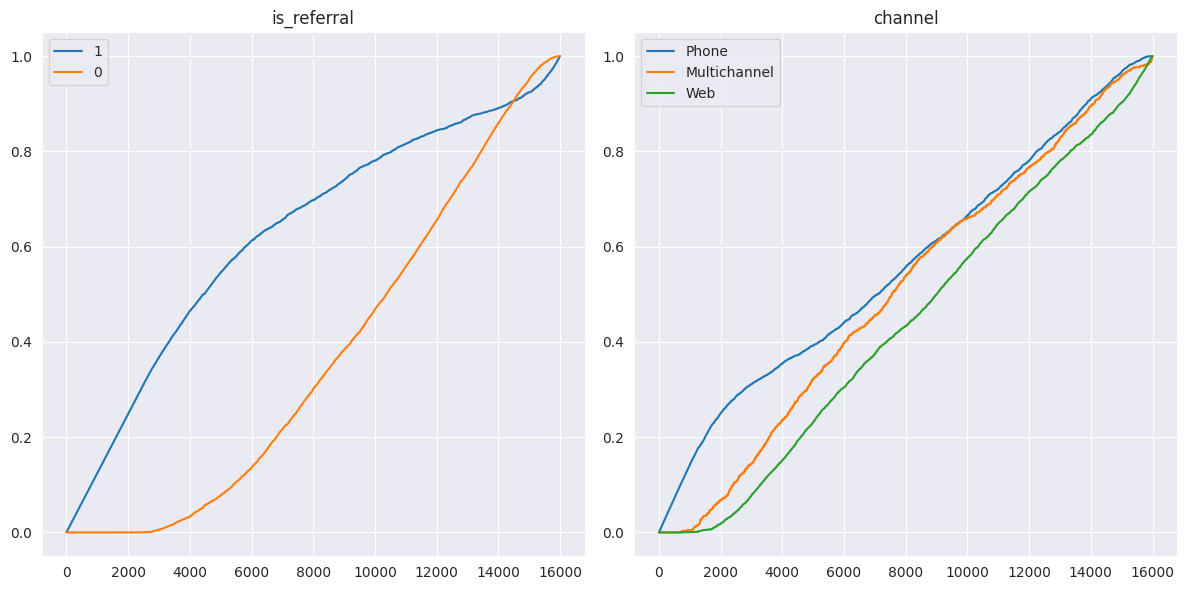

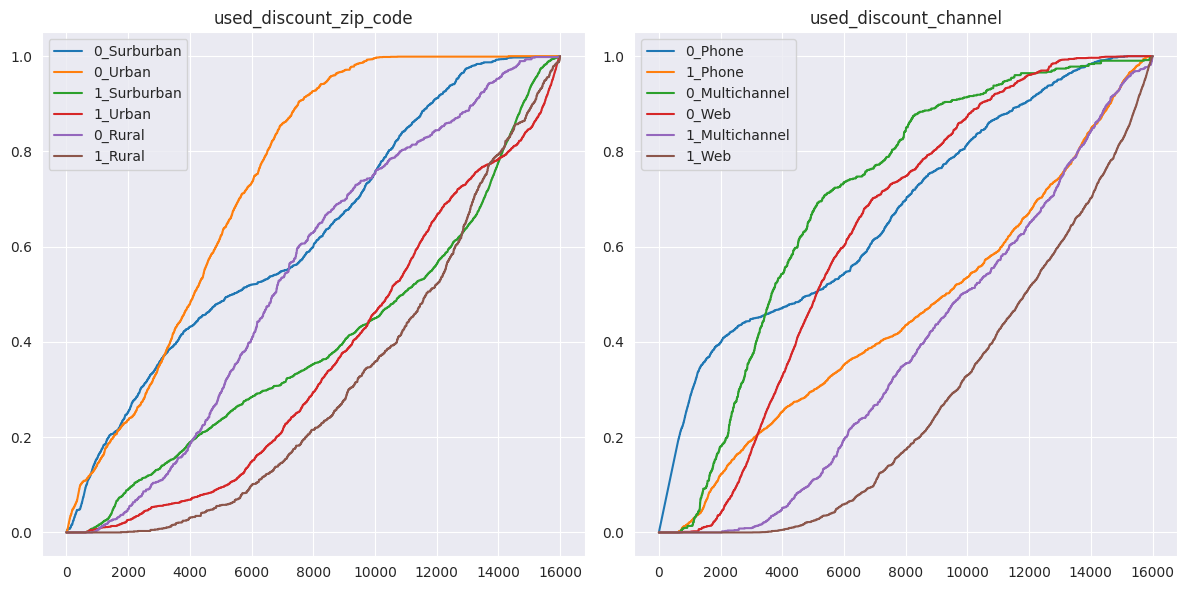

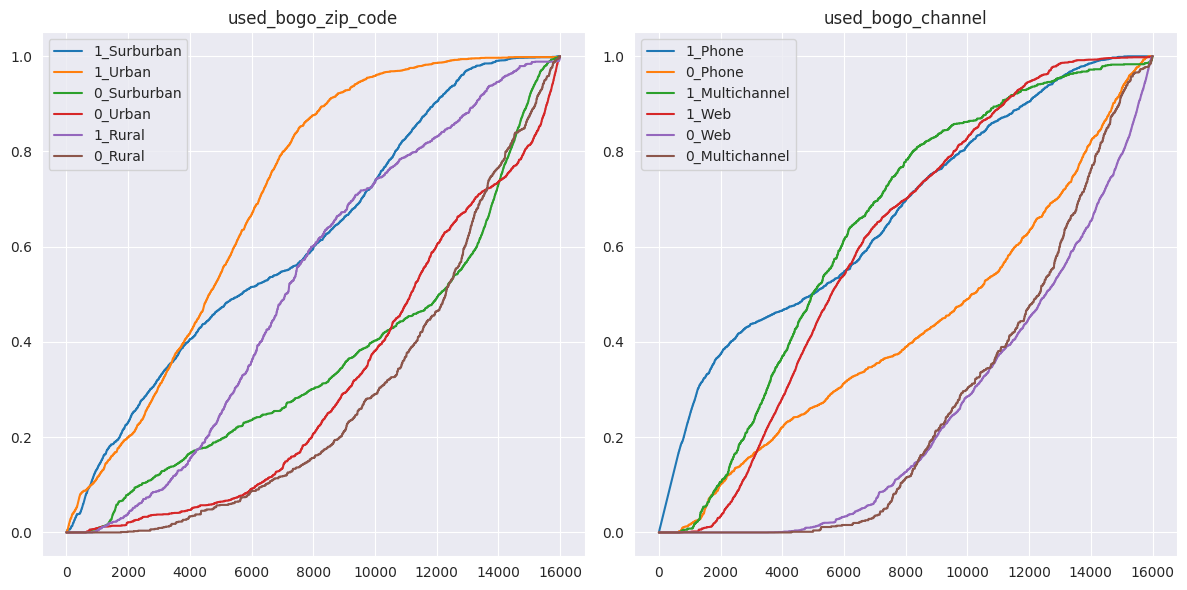

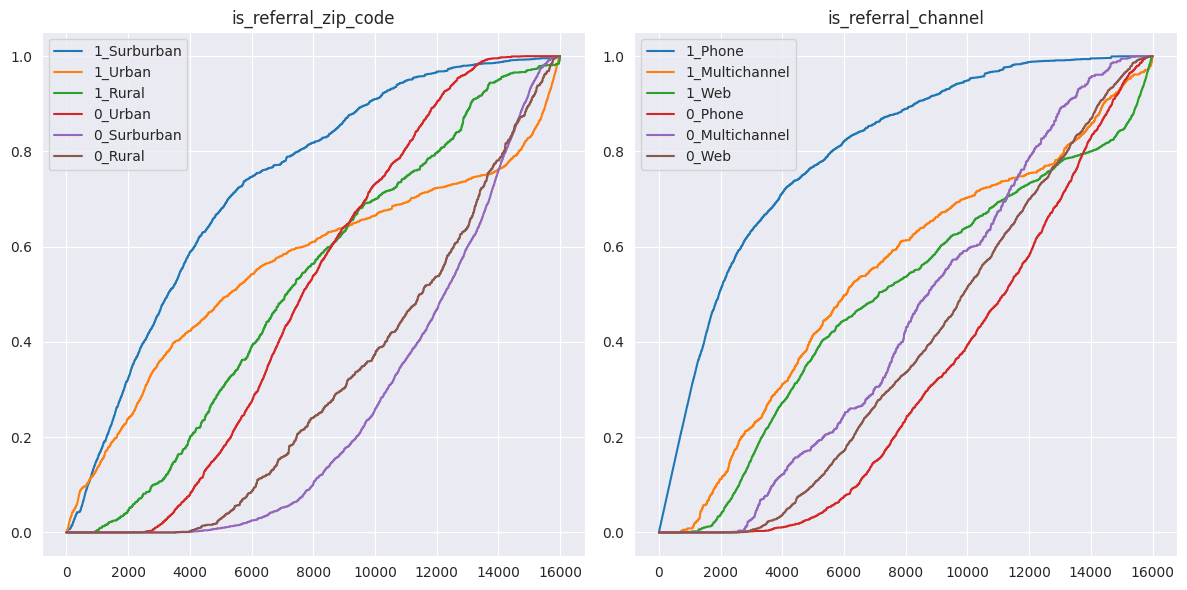

In [59]:
plot_cumulative_effects(df_test, cb_model_uplift, ncols=[2] * 7, qs={'recency': 3, 'history': 5})

Итак, усреднённый портрет клиента, которому модель собирается предложить оффер, выглядит следующим образом:
- Покупал что-то в последний раз не менее 8 месяцев назад
- Суммарно потратил не очень много денег (менее 115 долларов)
- Использовал ранее оба типа скидок
- Преимущетвенно горожанин или житель пригорода
- Нереферальный клиент
- В основном с ним держали связь по телефону

Теперь построим график uplift-AUC- и qini-кривых

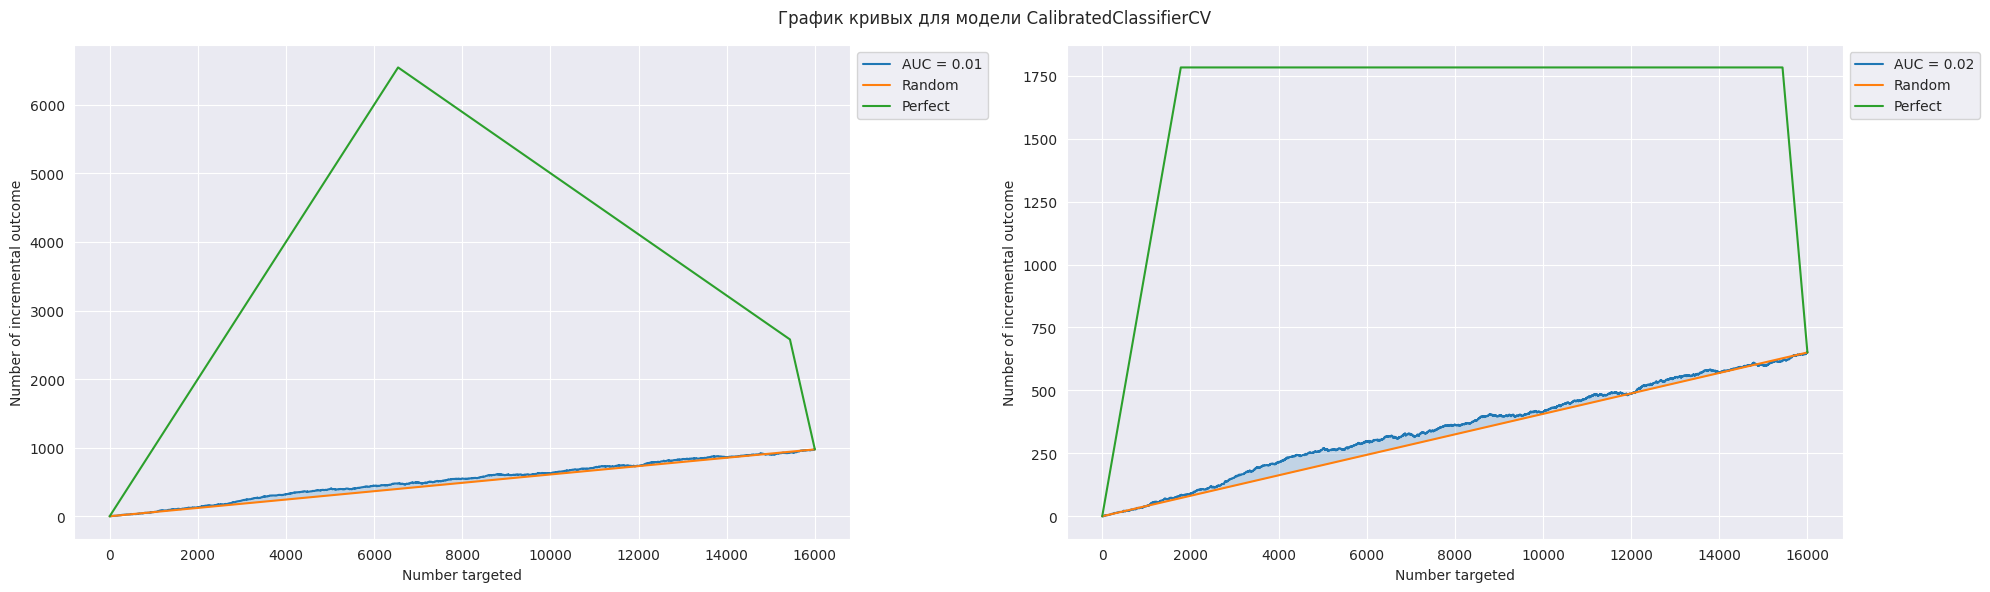

In [32]:
plot_curves(y_test, cb_model_uplift, treatment_test, cb_model.__class__.__name__)

Видим, что значения площадей получились маленькими, попробуем их немного увеличить

## Нейросети

Далее попробуем решить задачу с помощью 3 специфических для задачи uplift нейросетевых моделей

In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

Напишем свой класс датасета, чтобы подавать отдельно обучающую выборку, целевую переменную и вектор взаимодействий

In [34]:
class UpliftDataset(Dataset):
    def __init__(self, X, y, treatment):
        super().__init__()
        self.X = X
        self.y = y.astype(np.float32)
        self.treatment = treatment.astype(np.float32)

    def __getitem__(self, index):
        return {
            'index': self.X.index[index],
            'X': self.X.iloc[index].values.astype(np.float32),
            'y': self.y.iloc[index],
            'treatment': self.treatment.iloc[index]
        }

    def __len__(self):
        return self.X.shape[0]

Получим тренировочный, валидационный и тестовый датасеты

In [35]:
train_dataset = UpliftDataset(X_train, y_train, treatment_train)
valid_dataset = UpliftDataset(X_valid, y_valid, treatment_valid)
test_dataset = UpliftDataset(X_test, y_test, treatment_test)

Итак, мы хотим разделить стратифицированно батчи по вектору взаимодейтвия, для этого нужно написать свой сэмплер

In [36]:
class StratifiedBatchSampler:
    def __init__(
        self,
        class_vector,
        batch_size,
        random_state=random_state,
        shuffle=True
    ):
        if torch.is_tensor(class_vector):
            class_vector = class_vector.numpy()

        self.n_batches = int(len(class_vector) / batch_size)
        self.skf = StratifiedKFold(n_splits=self.n_batches, shuffle=shuffle)
        self.X = torch.randn(len(class_vector), 1).numpy()
        self.y = class_vector
        self.random_state = random_state
        self.shuffle = shuffle

    def __iter__(self):
        if self.shuffle:
            self.skf.random_state = self.random_state
        for _, test_idx in self.skf.split(self.X, self.y):
            yield test_idx

    def __len__(self):
        return self.n_batches

Получим тренировочный, валидационный и тестовый даталодеры

In [37]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_sampler=StratifiedBatchSampler(treatment_train, batch_size=1024)
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_sampler=StratifiedBatchSampler(treatment_valid, batch_size=1024)
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_sampler=StratifiedBatchSampler(treatment_test, batch_size=1024)
)

Итак, это абстрактный класс, являющийся каркасом далее разбираемых нейросетевых моделей для задачи uplift-моделирования, в нём определена архитектура слоёв. функции обучения и предсказания

Более подробно каждая нейросеть будет разбираться далее

In [38]:
class NeuralCausalModel(ABC, nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.common_head = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=256),
        )
        self.treatment_head = nn.Sequential(
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=1),
        )
        self.control_head = nn.Sequential(
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=1),
        )

    @staticmethod
    @abstractmethod
    def criterion(batch_pred, batch_true, **kwargs):
        pass

    @abstractmethod
    def return_dictionary(self, X, output):
        pass

    def forward(self, X, treatment=None):
        X = self.common_head(X)
        if treatment is None:
            T = self.treatment_head(X)[:, 0]
            C = self.control_head(X)[:, 0]
            return torch.sigmoid(T) - torch.sigmoid(C)
        treatment_mask = treatment == 1
        output = torch.zeros_like(treatment)
        output[treatment_mask] = self.treatment_head(X[treatment_mask])[:, 0]
        output[~treatment_mask] = self.control_head(X[~treatment_mask])[:, 0]
        return self.return_dictionary(X, output)

    def fit(
        self,
        train_dataloader,
        valid_dataloader,
        num_epochs,
        **optimizer_kwargs
    ):
        device = next(self.parameters()).device
        optimizer = AdamW(self.parameters(), **optimizer_kwargs)
        train_losses, valid_losses = [], []
        for epoch in range(1, num_epochs + 1):
            print(f'Тренировка на эпохе номер {epoch}...')
            local_loss = 0
            for batch_true in tqdm(train_dataloader):
                for key in batch_true.keys():
                    batch_true[key] = batch_true[key].to(device)
                optimizer.zero_grad()
                batch_pred = self.forward(
                    batch_true['X'],
                    treatment=batch_true['treatment']
                )
                loss = self.criterion(batch_pred, batch_true)
                local_loss += loss.item()
                loss.backward()
                optimizer.step()
            train_losses.append(local_loss / len(train_dataloader))

            self.eval()
            with torch.no_grad():
                print(f'Валидация на эпохе номер {epoch}...')
                local_loss = 0
                for batch_true in tqdm(valid_dataloader):
                    for key in batch_true.keys():
                        batch_true[key] = batch_true[key].to(device)
                    batch_pred = self.forward(
                        batch_true['X'],
                        treatment=batch_true['treatment']
                    )
                    loss = self.criterion(batch_pred, batch_true)
                    local_loss += loss.item()
                valid_losses.append(local_loss / len(valid_dataloader))
            self.train()

            clear_output(wait=True)

            ax = plt.subplots(figsize=(12, 6))[1]
            ax.plot(
                range(1, epoch + 1),
                train_losses,
                color='blue',
                label='Train'
            )
            ax.plot(
                range(1, epoch + 1),
                valid_losses,
                color='orange',
                label='Valid'
            )
            ax.legend()
            plt.show()

    def predict(self, test_dataloader, index):
        device = next(self.parameters()).device
        preds = pd.Series(index=index)
        self.eval()
        with torch.no_grad():
            print('Предсказание uplift для тестовой выборки...')
            for batch in tqdm(test_dataloader):
                for key in batch.keys():
                    if key != 'index':
                        batch[key] = batch[key].to(device)
                output = self.forward(batch['X'])
                preds.loc[batch['index'].numpy()] = output.cpu().numpy()
        self.train()
        return preds

### TARNet

Первой из разобранных моделей будет TARNet

На этапе обучения на вход подаётся вектор признаков, который сначала последовательно проходит через слои, а потом разделяется на 2 части в зависимости от того, принадлежит ли объект контрольной или целевой группе. Далее в зависимости от разделения объект проходит через линейные слои в "целевой" или "контрольной" последовательности слоёв и каждая последовательность учится решать задачу бинарной класификации - было ли взаимодействие или нет

На этапе предсказания объект проходит через обе головы и uplift score для него - это просто разность значений из "целевой" и "контрольной" последовательностей

![](https://towardsdatascience.com/wp-content/uploads/2024/03/1P7vrrbos3NqEpqsLC4a0vA-1024x400.png)

Этот пдход улучшает следующие концепции:
1) S-Learner (одна модель)

   Флаг воздействия передаётся как один из признаков наряду с сотнями других. Часто модель просто «игнорирует» его или её эффект «растворяется», из-за чего точный инкрементальный отклик (сам uplift) оценить сложно

![](https://habrastorage.org/r/w1560/webt/6l/ee/fn/6leefn5tmxbjoiipple65rgs1wc.png)

2) T-Learner (две модели)

   Обучаются две разные модели — одна на целевой группе, другая на контрольной. Проблема в том, что они не делятся знаниями - если целевая группа маленькая, модель для целевой группы переобучится или будет слабо выявлять паттерны

![](https://habrastorage.org/r/w1560/webt/pu/d0/o7/pud0o7dw88a-50xzndgzkxi6-mi.png)

Итак, определим класс модели

In [39]:
class TARNet(NeuralCausalModel):
    def __init__(self, in_features):
        super().__init__(in_features)

    @staticmethod
    def criterion(batch_pred, batch_true):
        y_true_control, y_true_treatment = (
            batch_true['y'][batch_true['treatment'] == 0],
            batch_true['y'][batch_true['treatment'] == 1]
        )
        y_pred_control, y_pred_treatment = (
            batch_pred['y'][batch_true['treatment'] == 0],
            batch_pred['y'][batch_true['treatment'] == 1]
        )
        loss = (
            F.binary_cross_entropy_with_logits(
                y_pred_treatment,
                y_true_treatment
            ) +
            F.binary_cross_entropy_with_logits(
                y_pred_control,
                y_true_control
            )
        )
        return loss

    def return_dictionary(self, X, output):
        return {'y': output}

Создадим объект модели и обучим его

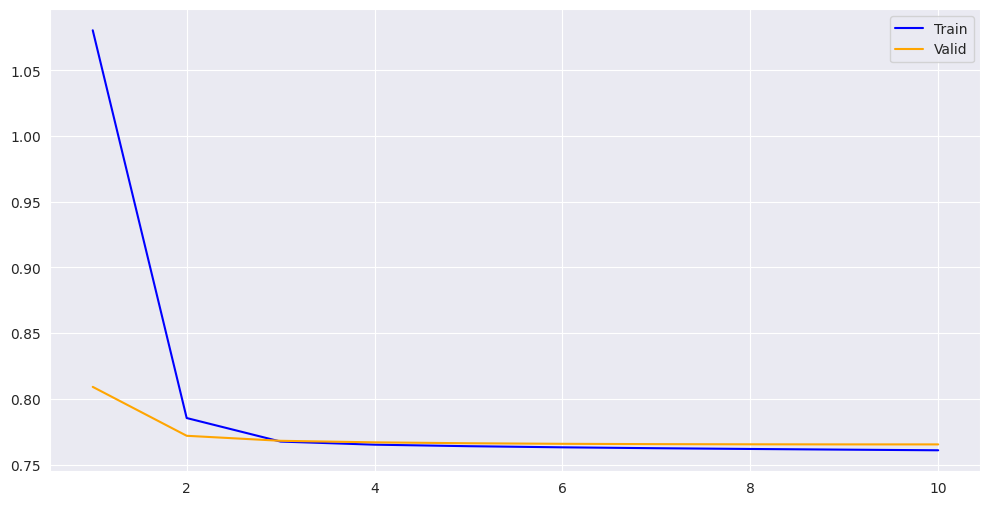

Предсказание uplift для тестовой выборки...


  0%|          | 0/15 [00:00<?, ?it/s]

In [40]:
tarnet = TARNet(X_train.shape[1]).to(device)
tarnet.fit(train_dataloader, valid_dataloader, 10, lr=3e-4, amsgrad=True)
tarnet_uplift = tarnet.predict(test_dataloader, X_test.index)

In [41]:
metrics = get_metrics(
    y_test,
    tarnet_uplift,
    treatment_test,
    tarnet.__class__.__name__,
    metrics=metrics
)

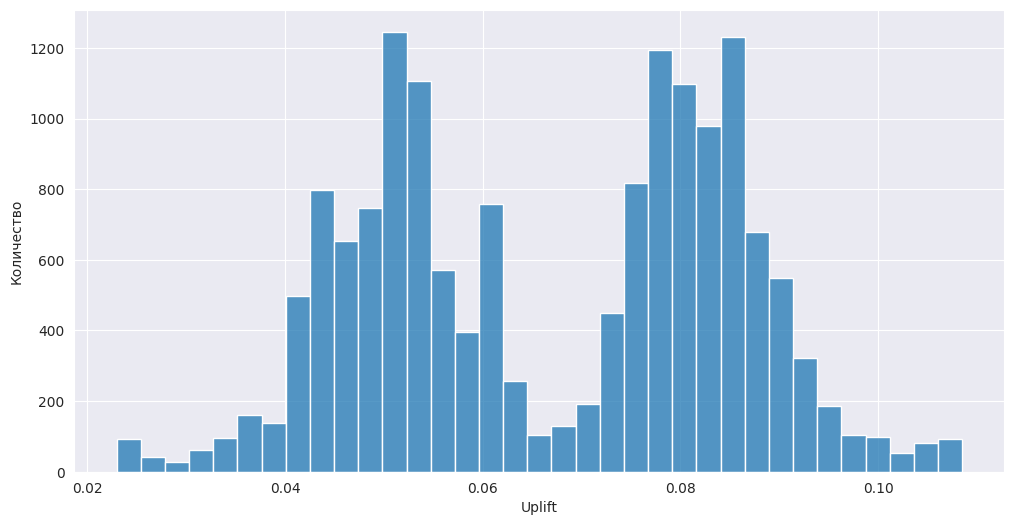

In [42]:
uplift_histplot(tarnet_uplift)

А здесь уже кардинально другая картина - отрицательного эффекта по мнению модели нет вообще, а максимальный немногим превышает 0.1

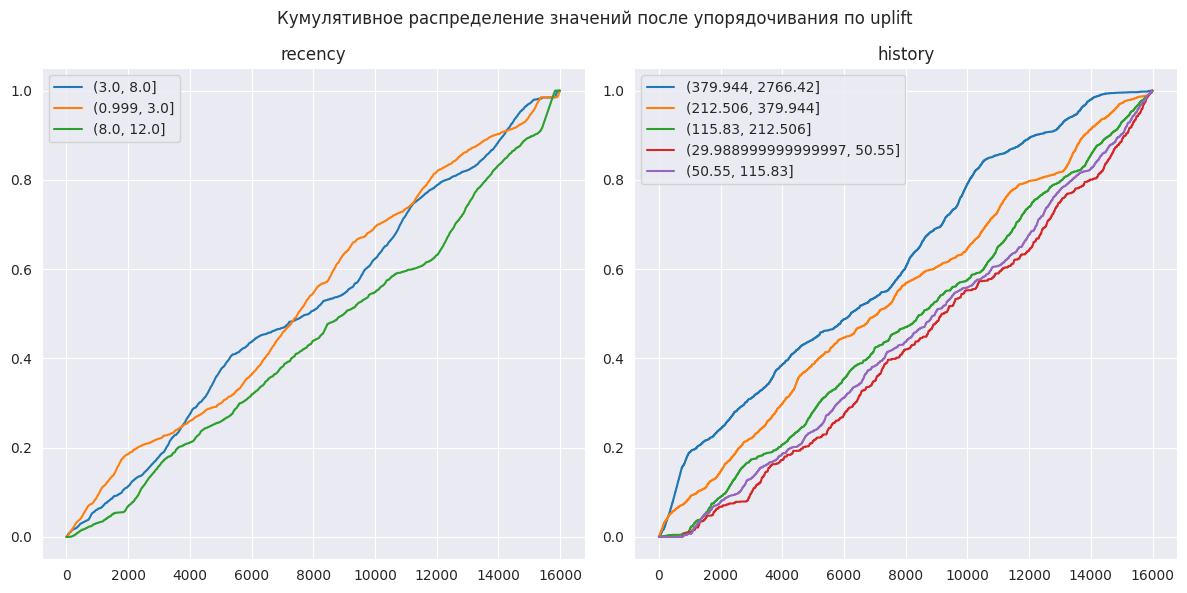

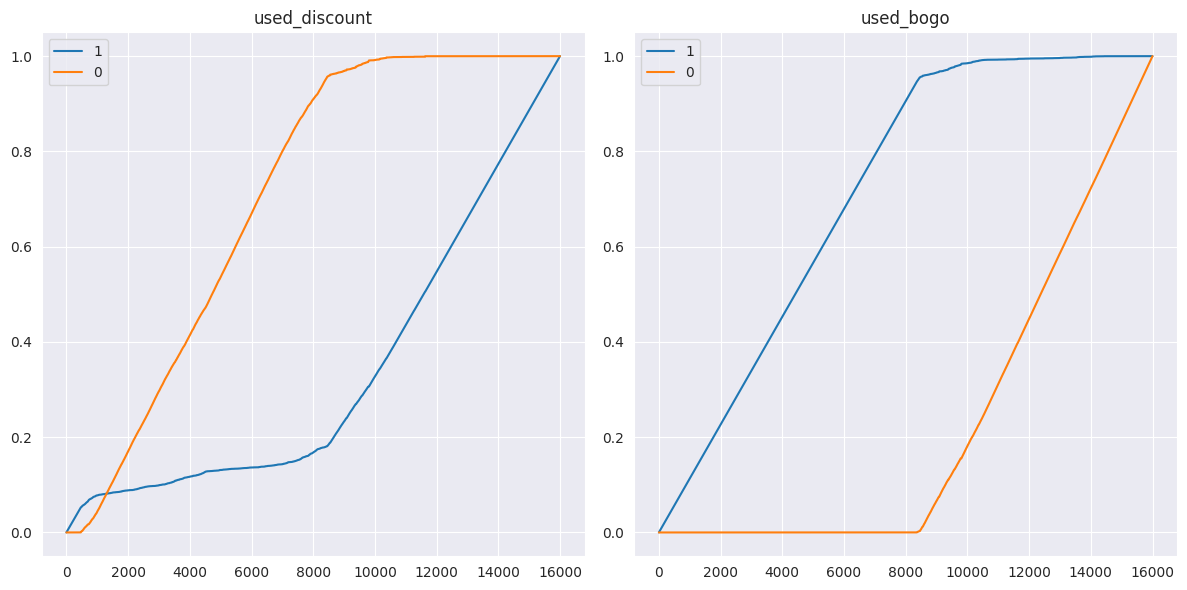

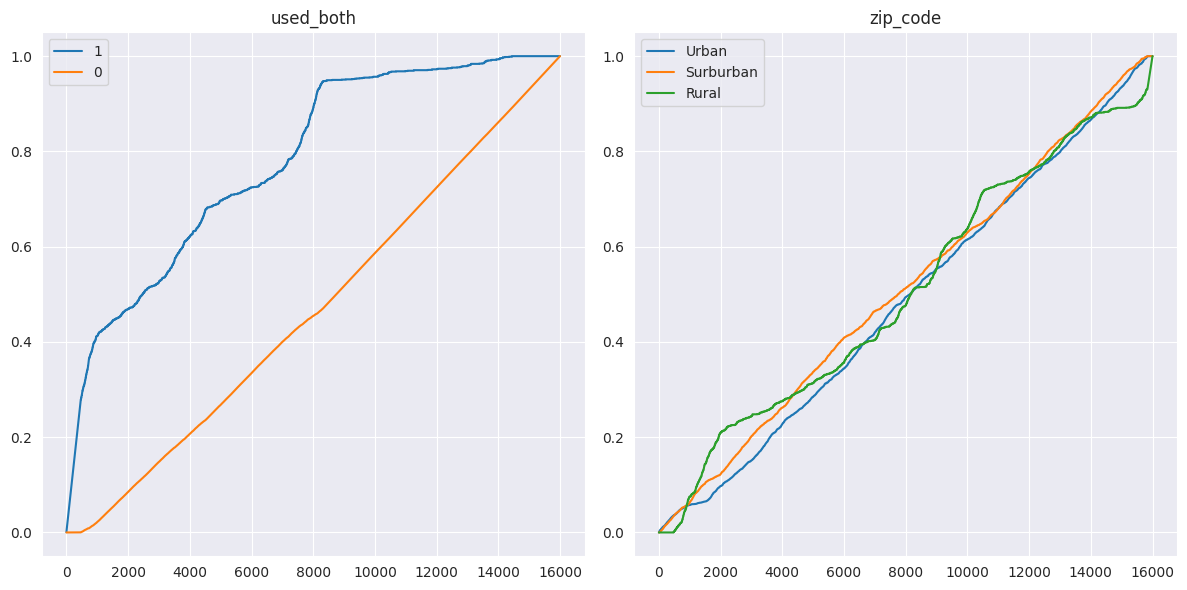

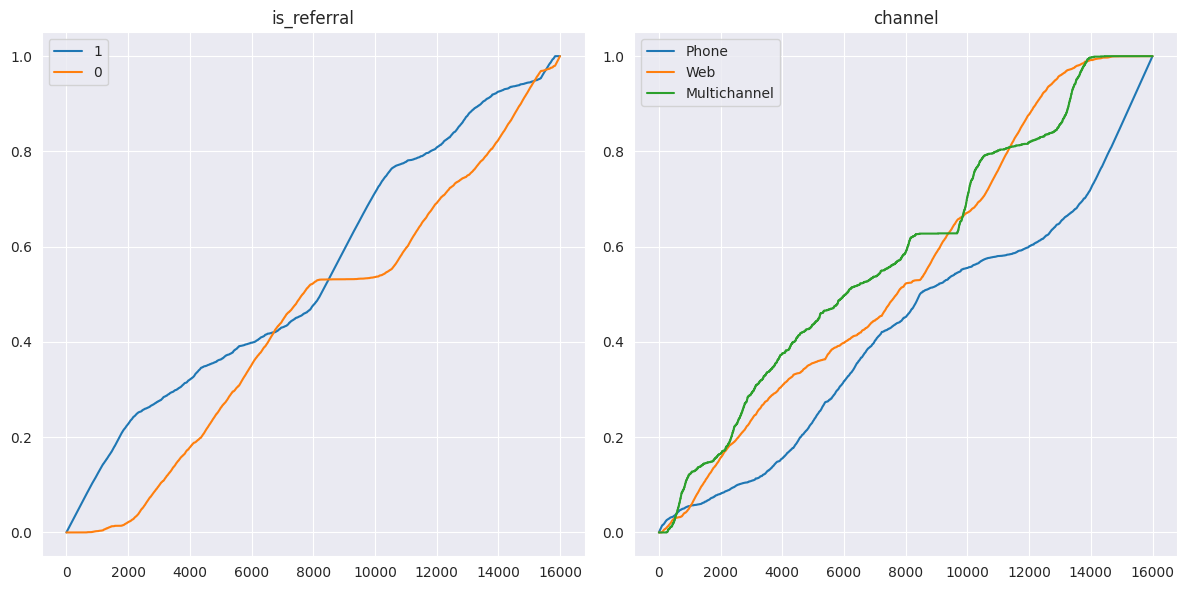

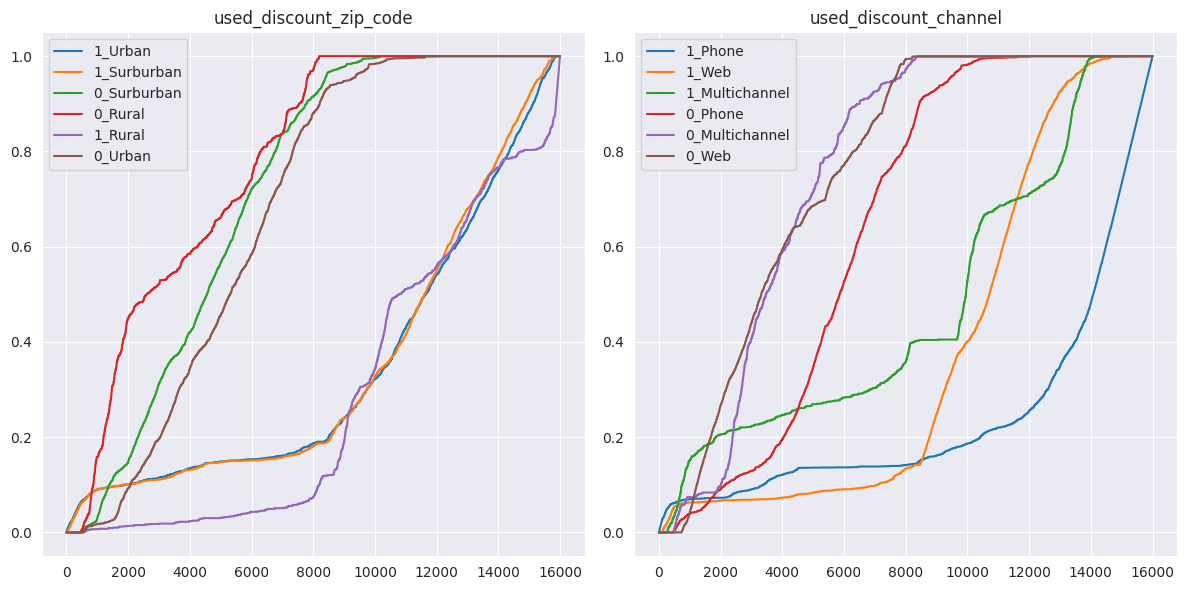

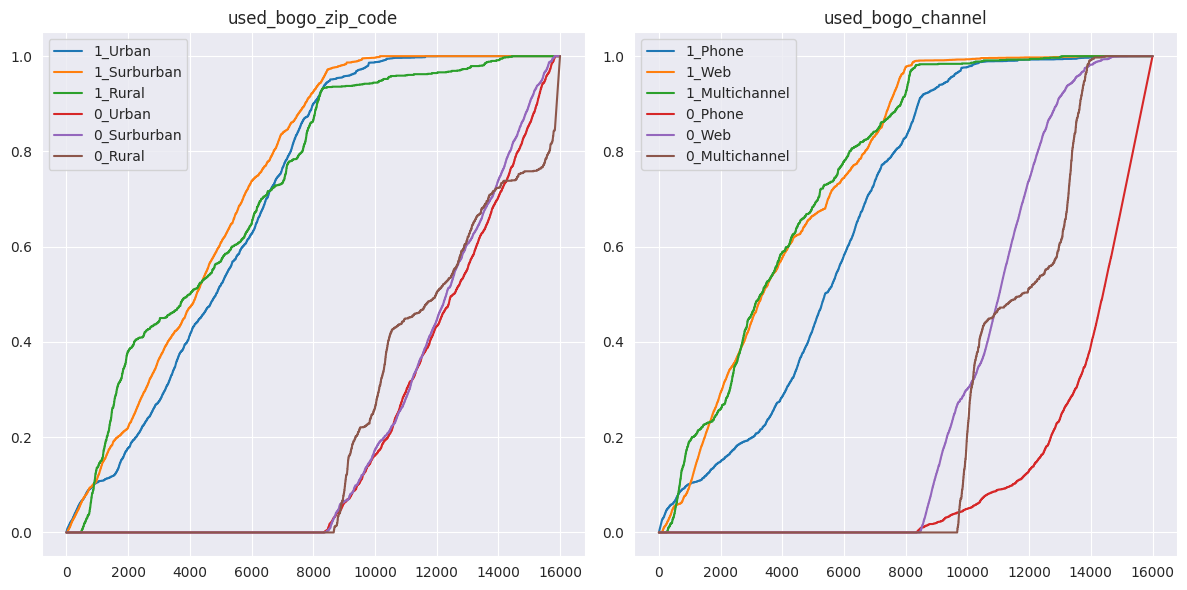

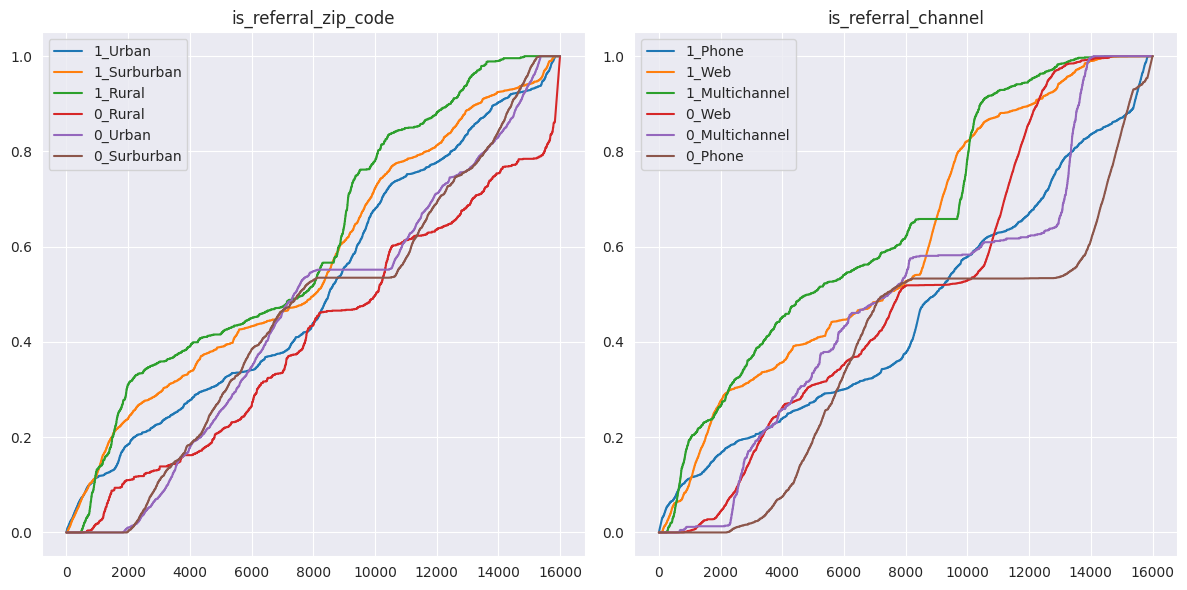

In [60]:
plot_cumulative_effects(df_test, tarnet_uplift, ncols=[2] * 7, qs={'recency': 3, 'history': 5})

Здесь усреднённый портрет клиента, которому модель собирается предложить оффер, выглядит так:
- Покупал что-то в последний раз не более 3 месяцев назад
- Суммарно потратил много денег (более 212 долларов)
- Не использовал скидку, но использовал акцию BOGO
- Преимущеcтвенно горожанин или житель пригорода, но быстро сменяется сельским жителем
- Нереферальный клиент
- В основном с ним держали связь и по телефону, и по интернету

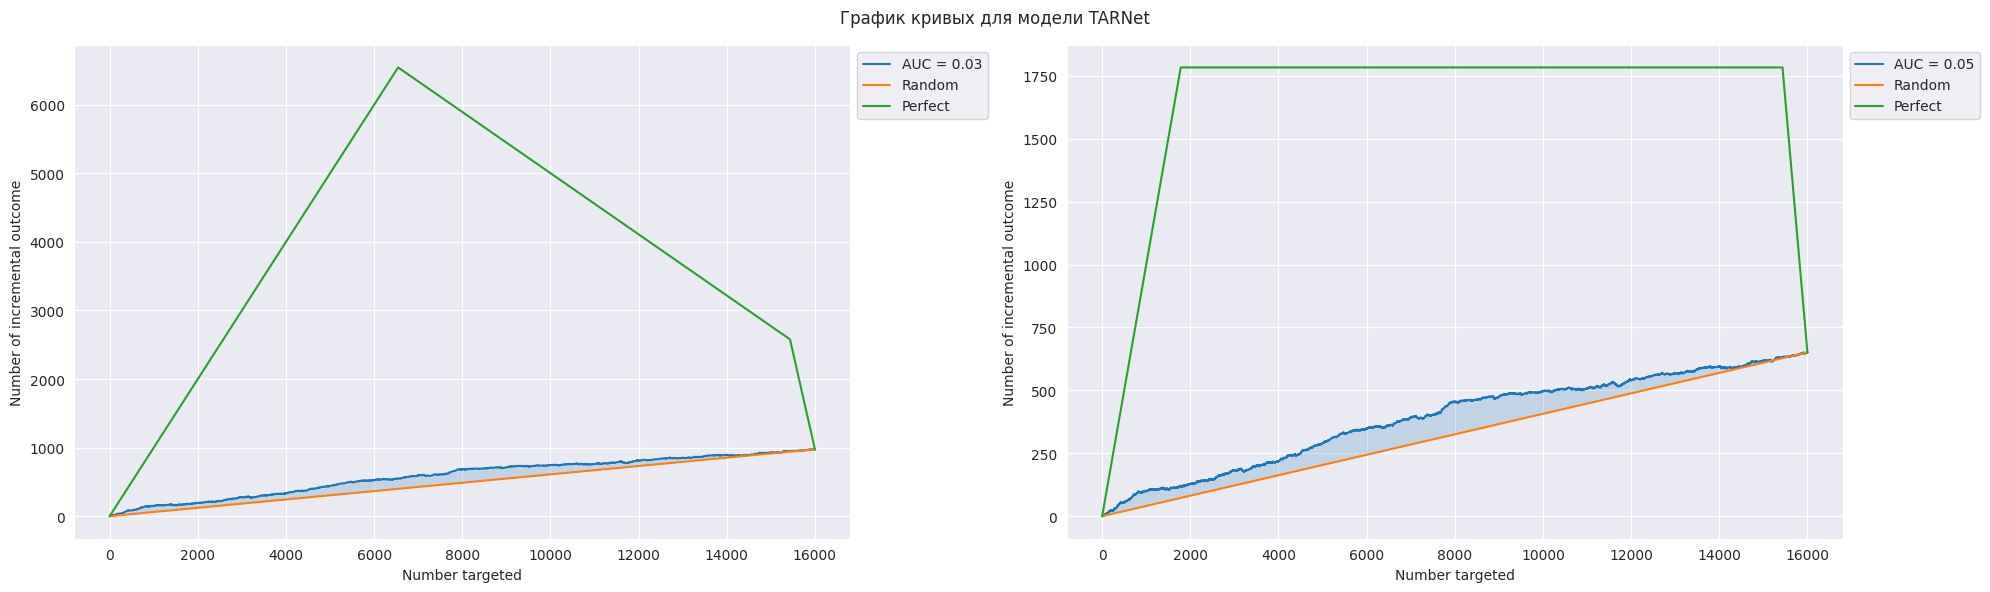

In [44]:
plot_curves(
    y_test,
    tarnet_uplift,
    treatment_test,
    tarnet.__class__.__name__
)

Итак, видим серьёзное улучшение. Например, значение метрики qini-score поднялось почти в 3 раза

### CFRNet

CFRNet повторяет архитектуру TARNet, однако добавляет в функцию потерь ещё регуляризационное слагаемое, измеряющее растояние между распределениями скрытых представлений в целевой и контрольной группах

То есть общий слой должен трансформировать входной вектор признаков так, чтобы после трансформации невозможно было отличить, из целевой или контрольной группы пришёл объект

Добавляется эта разноть с помощью такого инструмента, как MMD (Maximum Mean Discrepancy) - разности средних значений в специальном гильбертовом пространстве (в моём случае используется радиальная базиная функция)

Для двух выборок скрытых представлений $\large{\mathbf{Z}_0 = \{z_0^{(i)}\}_{i=1}^{n_0}}$ и $\large{\mathbf{Z}_1 = \{z_1^{(j)}\}_{j=1}^{n_1}}$ с гауссовским ядром $\large{k(x, y) = \exp\left(-\frac{\Vert{}x - y\Vert{}^2}{2\sigma^2}\right)}$, квадрат MMD рассчитывается по формуле:

$$\text{MMD}^2(\mathbf{Z}_0, \mathbf{Z}_1) = \frac{1}{n_0^2} \sum_{i=1}^{n_0} \sum_{i'=1}^{n_0} k\left(z_0^{(i)}, z_0^{(i')}\right) + \frac{1}{n_1^2} \sum_{j=1}^{n_1} \sum_{j'=1}^{n_1} k\left(z_1^{(j)}, z_1^{(j')}\right) - \frac{2}{n_0 n_1} \sum_{i=1}^{n_0} \sum_{j=1}^{n_1} k\left(z_0^{(i)}, z_1^{(j)}\right)$$

Что означают слагаемые:
- Первые два слагаемых — это «внутригрупповое сходство» (насколько объекты внутри каждой из групп похожи друг на друга)
- Третье слагаемое — это «межгрупповое сходство» (насколько объекты из контрольной группы похожи на объекты из целевой)

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQwTsdst9yap9iu-Y6b7lPm2teslnzN4sW9gS4w2o5k-d-Gc9-vN9NHxPE&s=10)

In [45]:
class CFRNet(NeuralCausalModel):
    def __init__(self, in_features):
        super().__init__(in_features)

    @staticmethod
    def get_kernel(x, y):
        m_x, m_y = (
            torch.square(x).sum(axis=1, keepdim=True),
            torch.square(y).sum(axis=1, keepdim=True)
        )
        dist = (m_x.T + m_y).T - 2 * x @ y.T
        gamma = 1 / (2.0 * torch.square(torch.median(dist)))
        kernel = torch.exp(-gamma * dist)
        return kernel

    @staticmethod
    def rbf_loss(z0, z1):
        n0, n1 = z0.shape[0], z1.shape[1]
        k_z0 = CFRNet.get_kernel(z0, z0)
        k_z1 = CFRNet.get_kernel(z1, z1)
        k_z0_z1 = CFRNet.get_kernel(z0, z1)
        loss = (
            k_z0.sum() / (n0 * n0) +
            k_z1.sum() / (n1 * n1) -
            2.0 * k_z0_z1.sum() / (n0 * n1)
        )
        return loss

    @staticmethod
    def criterion(batch_pred, batch_true, alpha=1e-3):
        y_true_control, y_true_treatment = (
            batch_true['y'][batch_true['treatment'] == 0],
            batch_true['y'][batch_true['treatment'] == 1]
        )
        y_pred_control, y_pred_treatment = (
            batch_pred['y'][batch_true['treatment'] == 0],
            batch_pred['y'][batch_true['treatment'] == 1]
        )
        Z_pred_control, Z_pred_treatment = (
            batch_pred['Z'][batch_true['treatment'] == 0],
            batch_pred['Z'][batch_true['treatment'] == 1]
        )
        loss = (
            F.binary_cross_entropy_with_logits(
                y_pred_treatment,
                y_true_treatment
            ) +
            F.binary_cross_entropy_with_logits(
                y_pred_control,
                y_true_control
            ) +
            alpha * CFRNet.rbf_loss(
                Z_pred_control,
                Z_pred_treatment
            )
        )
        return loss

    def return_dictionary(self, X, output):
        return {'y': output, 'Z': X}

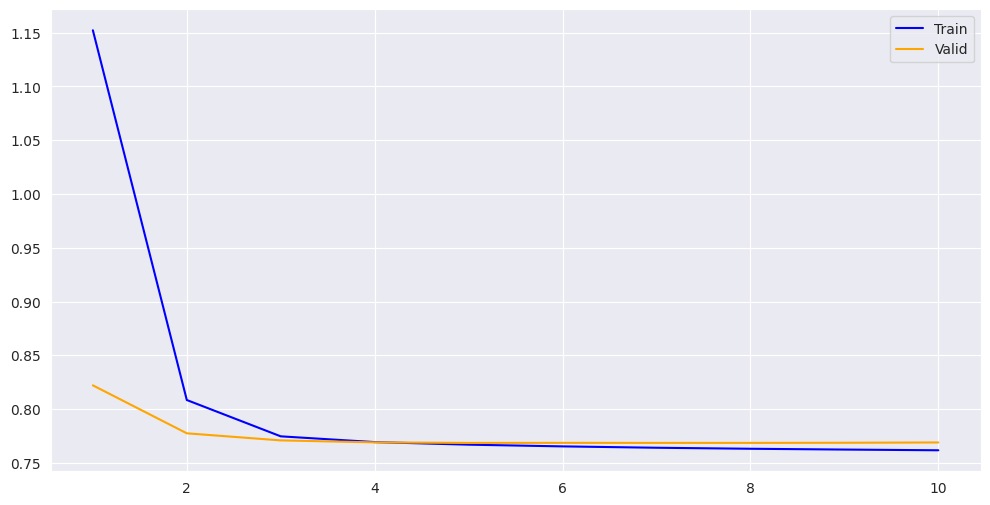

Предсказание uplift для тестовой выборки...


  0%|          | 0/15 [00:00<?, ?it/s]

In [46]:
cfrnet = CFRNet(X_train.shape[1]).to(device)
cfrnet.fit(train_dataloader, valid_dataloader, 10, lr=3e-4, amsgrad=True)
cfrnet_uplift = cfrnet.predict(test_dataloader, X_test.index)

In [47]:
metrics = get_metrics(
    y_test,
    cfrnet_uplift,
    treatment_test,
    cfrnet.__class__.__name__,
    metrics=metrics
)

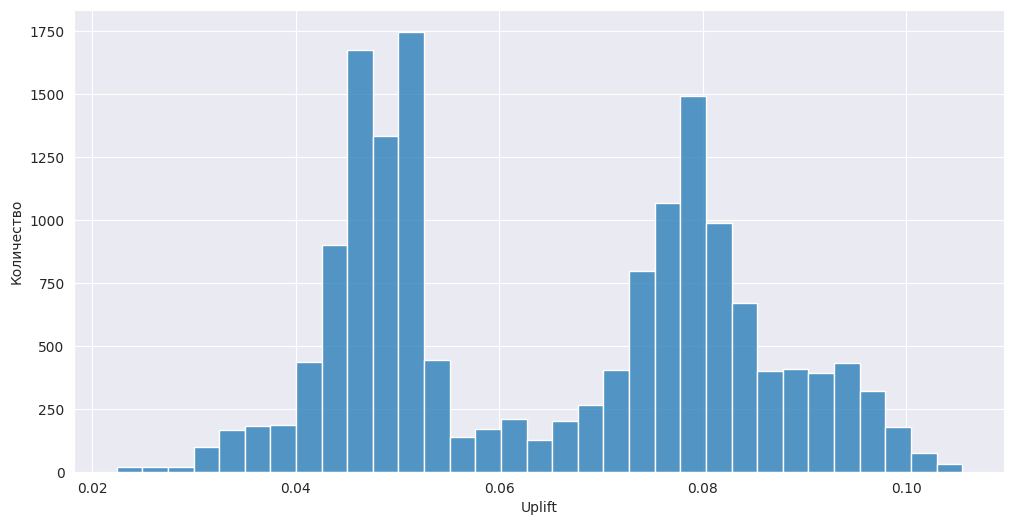

In [48]:
uplift_histplot(cfrnet_uplift)

Видим точно такой же бимодальный график в тех же масштабах, что и в предыдущем случае

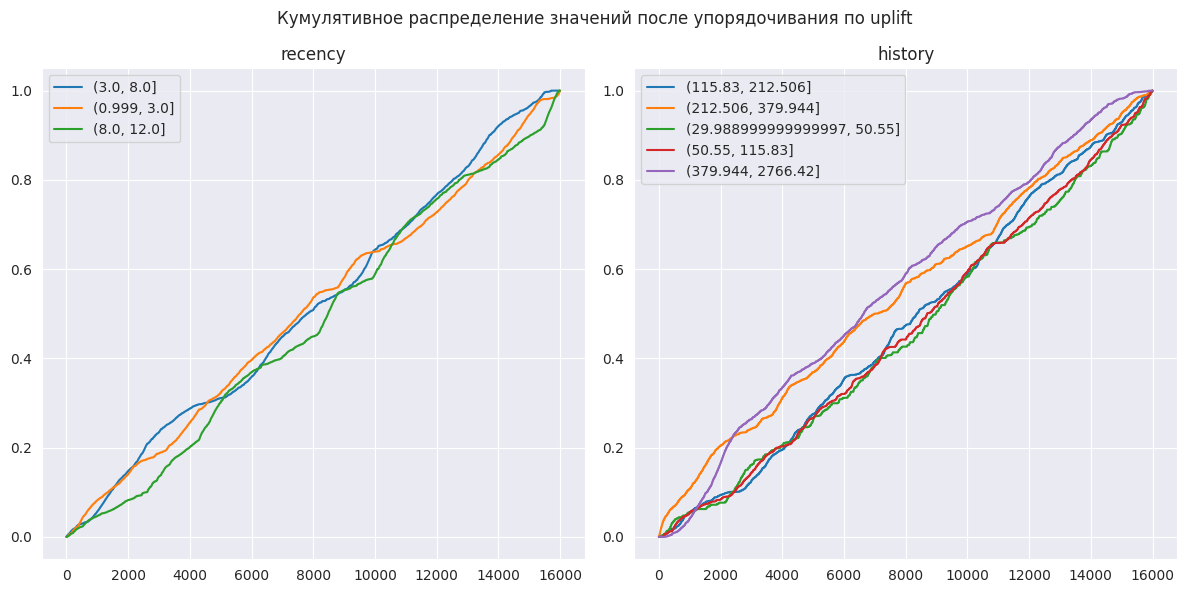

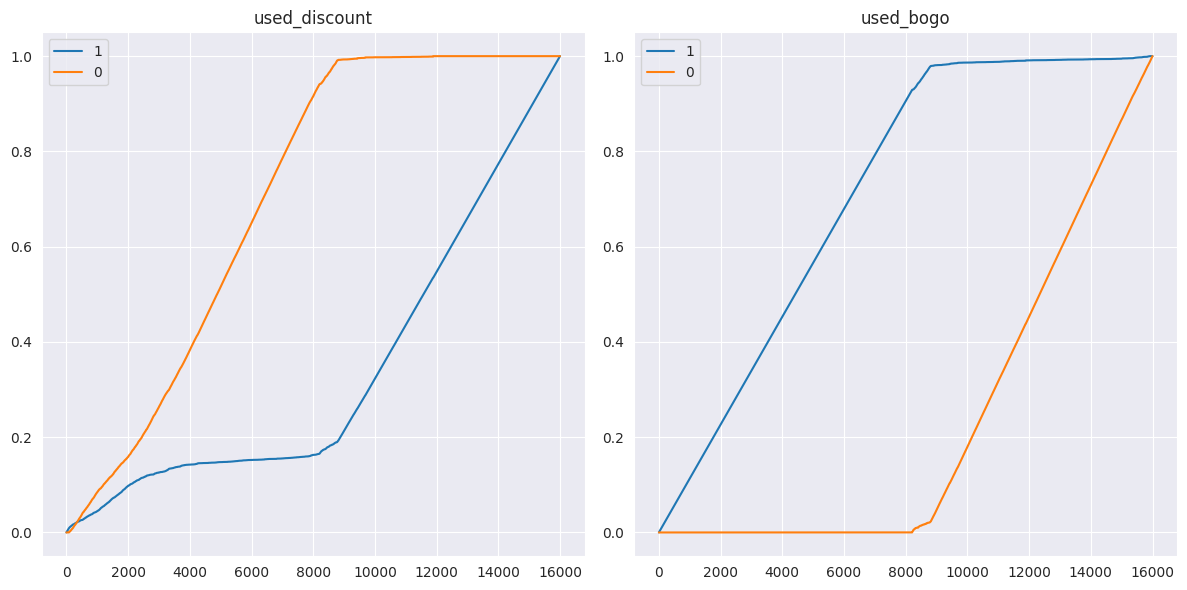

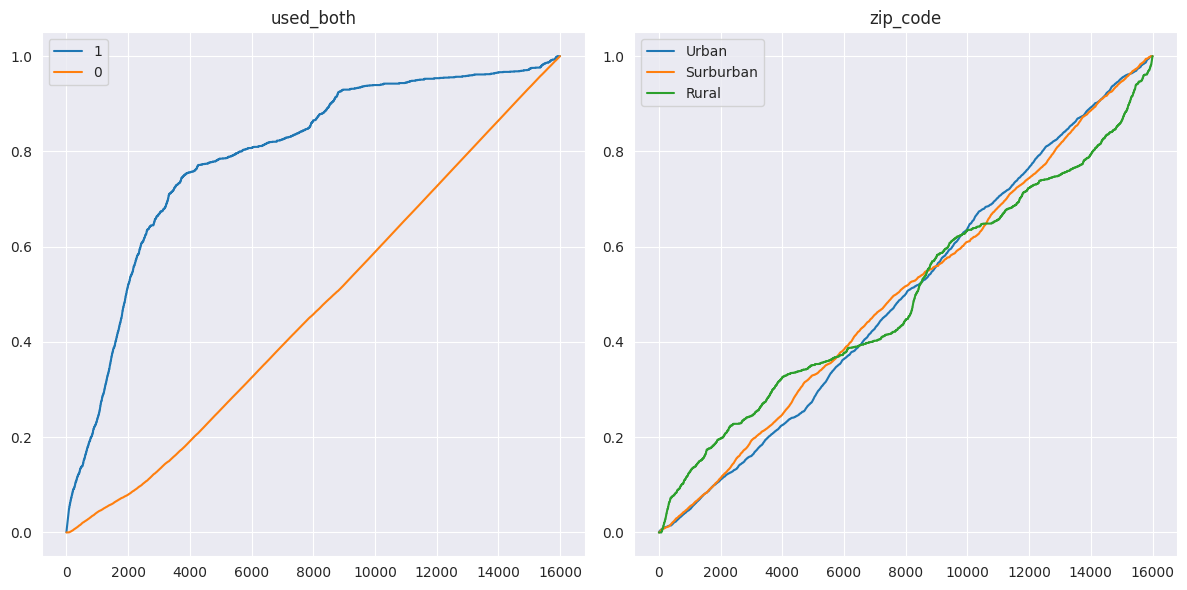

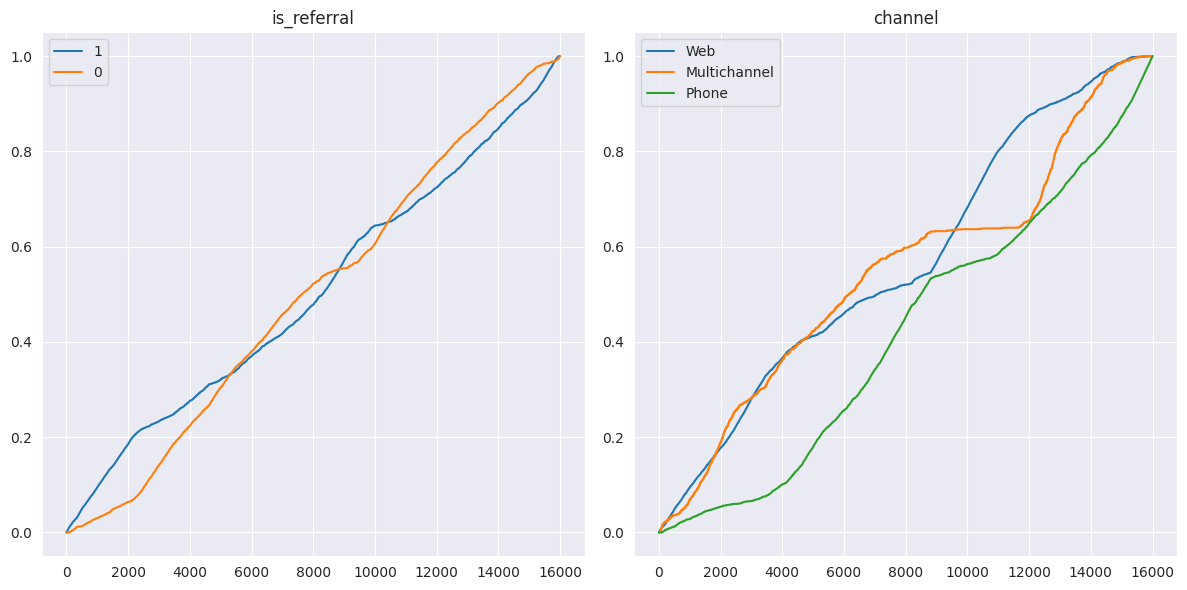

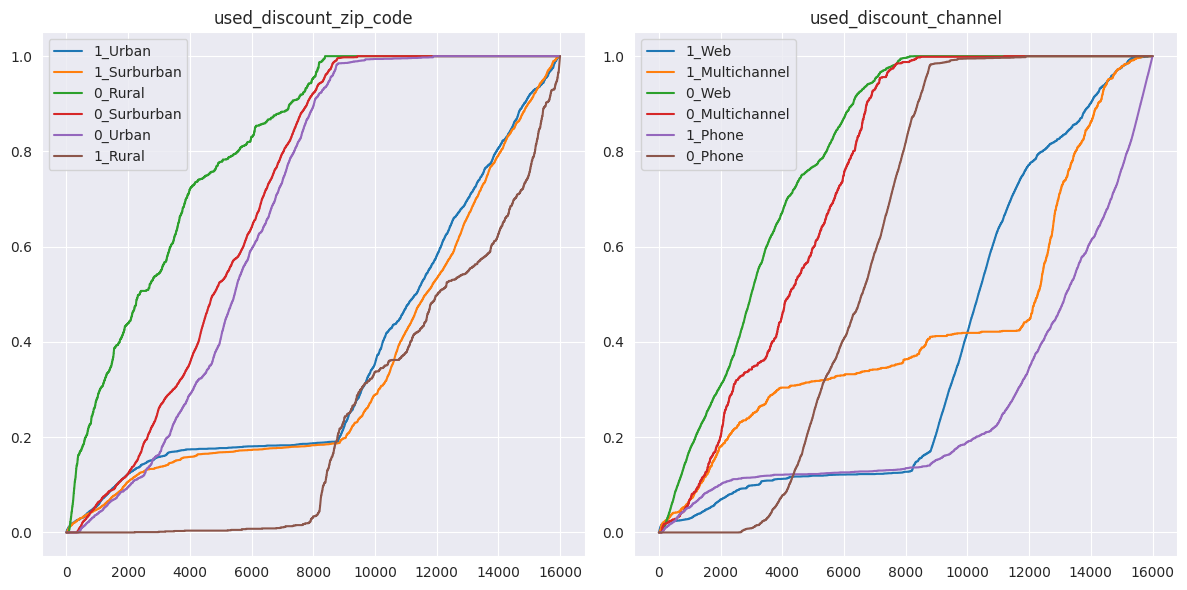

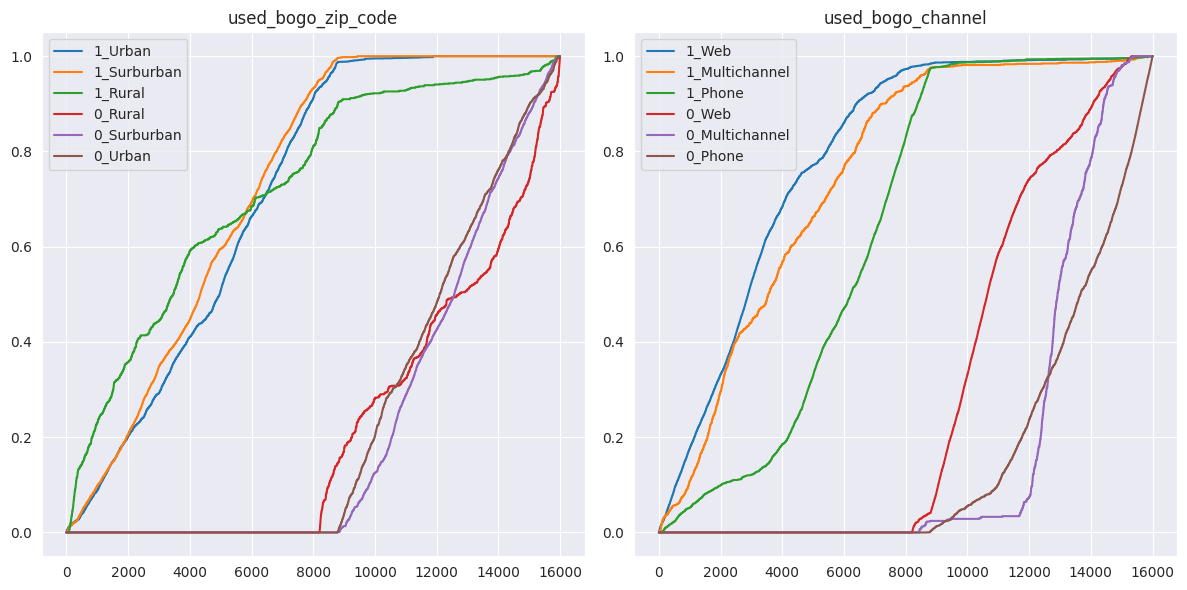

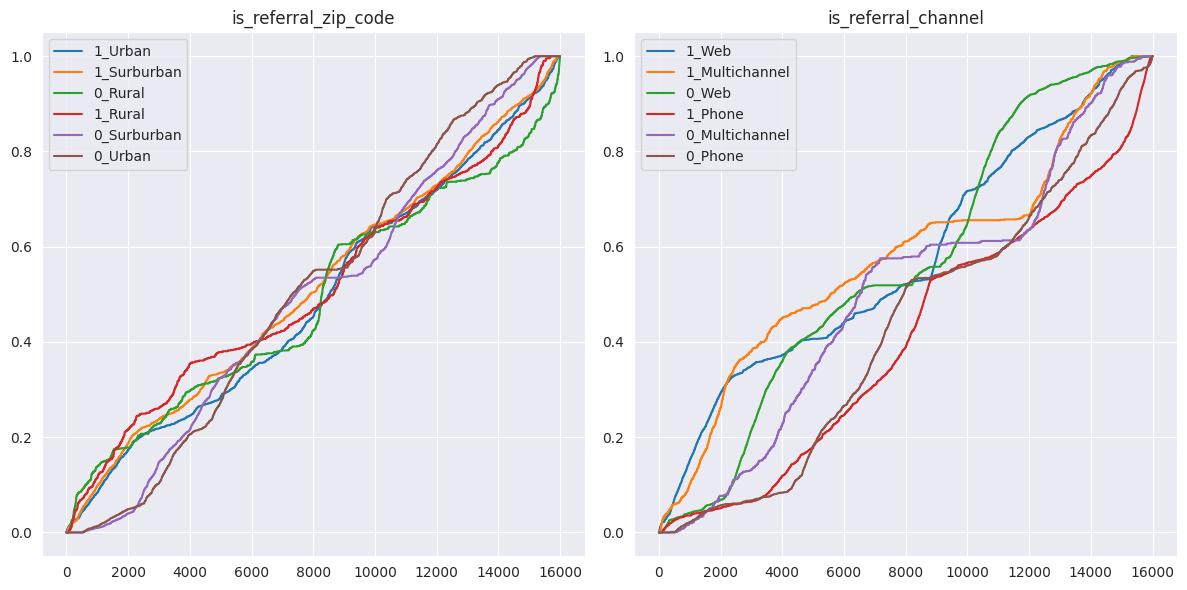

In [61]:
plot_cumulative_effects(df_test, cfrnet_uplift, ncols=[2] * 7, qs={'recency': 3, 'history': 5})

Здесь усреднённый портрет клиента, которому модель собирается предложить оффер, выглядит так:
- Покупал что-то в последний раз более 8 месяцев назад, но быстро сменяется тем клиентом, который покупал что-то в последний раз не более 3 месяцев назад
- Суммарно потратил не очень много денег (от 212 до 379 долларов)
- Не использовал скидку, но использовал акцию BOGO
- Преимущеcтвенно сельский житель
- В основном нереферальный клиент
- В основном с ним держали связь по интернету и по обоим каналам связи

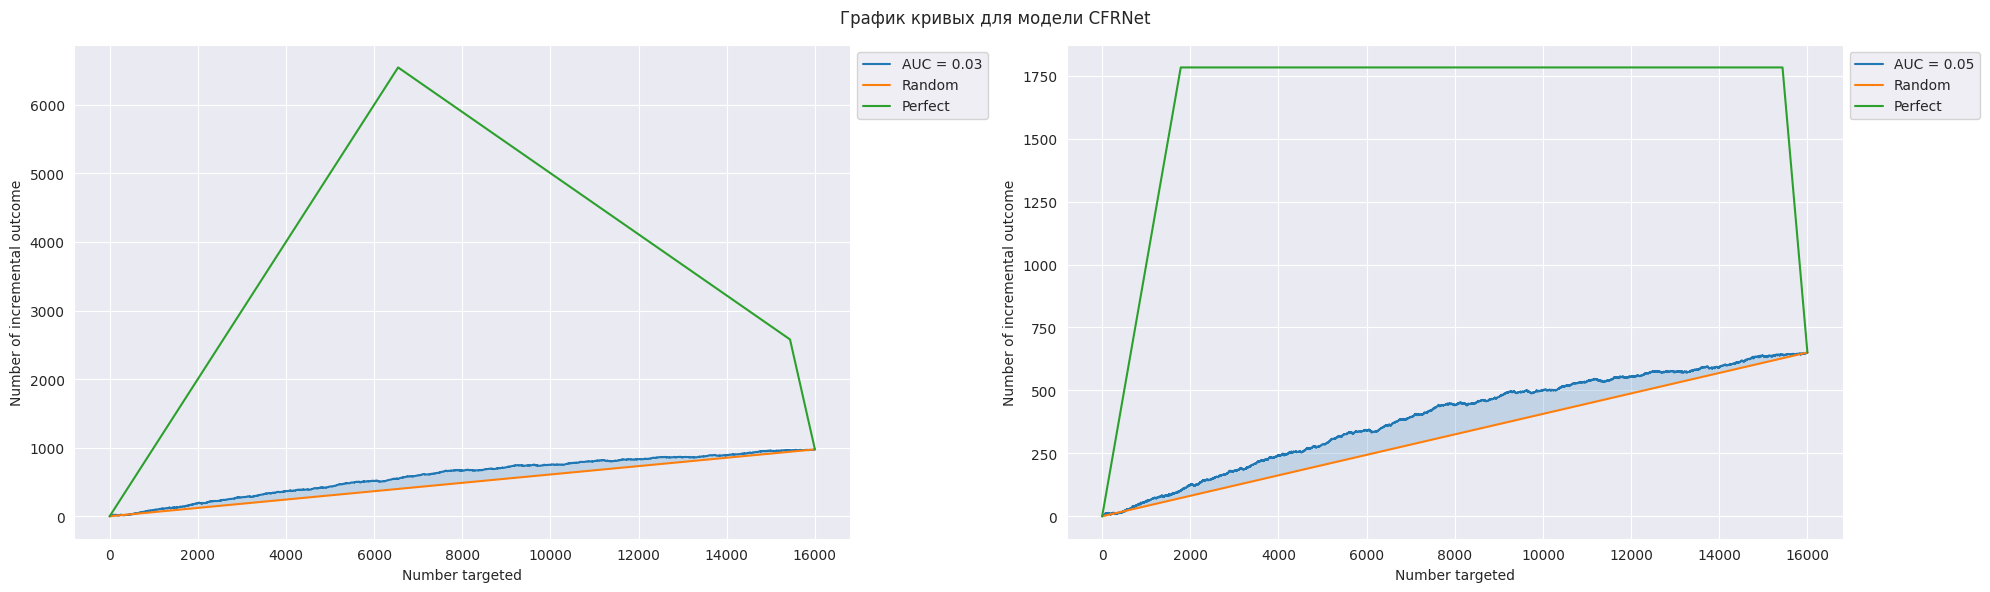

In [50]:
plot_curves(
    y_test,
    cfrnet_uplift,
    treatment_test,
    cfrnet.__class__.__name__
)

Существенного улучшения по сравнению с предыдущим лучаем не видим

### DragonNet

Идея очень похожа на идею, заложенную в TARNet, однако здесь ещё дополнительно на этапе обучения добавляется третья голова, которая учится правильно предсказывать то, принадлежит ли объект контрольной группе (в качестве функции потерь у этой головы также используется бинарная кросс-энтропия)

На этапе предсказания эта средняя голова игнорируется. То есть предсказание здесь аналогично тому, что используется в модели TARNet

Это небольшое изменение, заключающееся в добавлении третьей головы, вычисляющей вероятность получения лечения, регуляризует сеть таким образом, что она может более надежно оценивать улучшения, чем раньше. Сеть вынуждена выделять хорошее представление Z исходных данных X, чтобы средний блок мог делать точные прогнозы для оценки вероятности приобретения товара

![](https://towardsdatascience.com/wp-content/uploads/2024/03/1-L5MpFGpNkHZP7eCARl0OA.png)

In [51]:
class DragonNet(NeuralCausalModel):
    def __init__(self, in_features):
        super().__init__(in_features)
        self.h = nn.Linear(in_features=256, out_features=1)

    @staticmethod
    def criterion(batch_pred, batch_true):
        y_true_control, y_true_treatment = (
            batch_true['y'][batch_true['treatment'] == 0],
            batch_true['y'][batch_true['treatment'] == 1]
        )
        y_pred_control, y_pred_treatment = (
            batch_pred['y'][batch_true['treatment'] == 0],
            batch_pred['y'][batch_true['treatment'] == 1]
        )
        loss = (
            F.binary_cross_entropy_with_logits(
                y_pred_treatment,
                y_true_treatment
            ) +
            F.binary_cross_entropy_with_logits(
                y_pred_control,
                y_true_control
            ) +
            F.binary_cross_entropy_with_logits(
                batch_pred['h'],
                batch_true['treatment']
            )
        )
        return loss

    def return_dictionary(self, X, output):
        return {'y': output, 'h': self.h(X)[:, 0]}

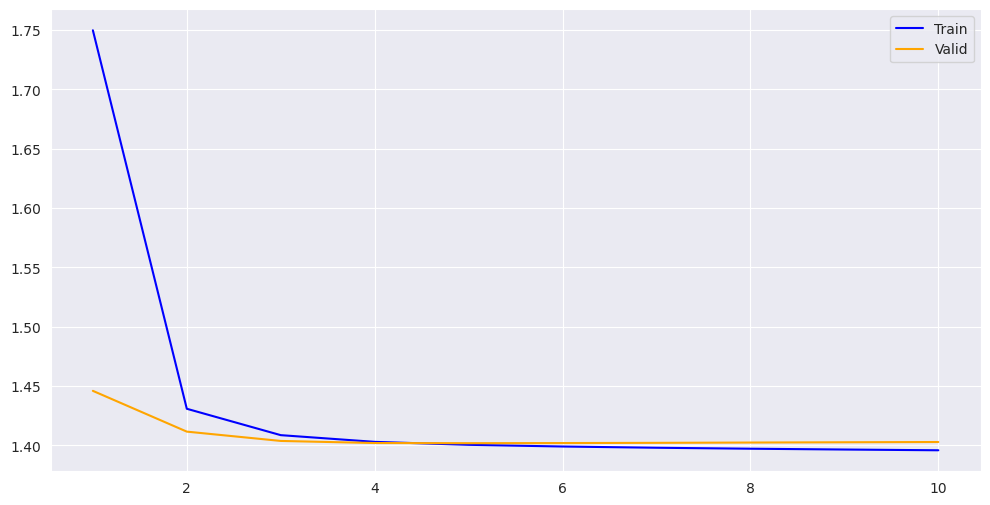

Предсказание uplift для тестовой выборки...


  0%|          | 0/15 [00:00<?, ?it/s]

In [52]:
dragonnet = DragonNet(X_train.shape[1]).to(device)
dragonnet.fit(train_dataloader, valid_dataloader, 10, lr=3e-4, amsgrad=True)
dragonnet_uplift = dragonnet.predict(test_dataloader, X_test.index)

In [53]:
metrics = get_metrics(
    y_test,
    dragonnet_uplift,
    treatment_test,
    dragonnet.__class__.__name__,
    metrics=metrics
)

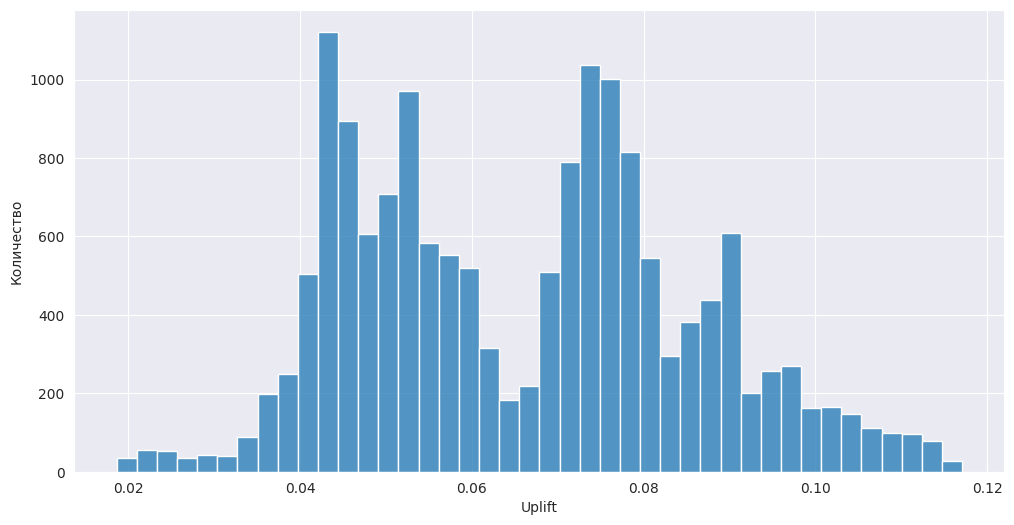

In [54]:
uplift_histplot(dragonnet_uplift)

Здесь "моды" стали потолще, однако масштаб не изменился

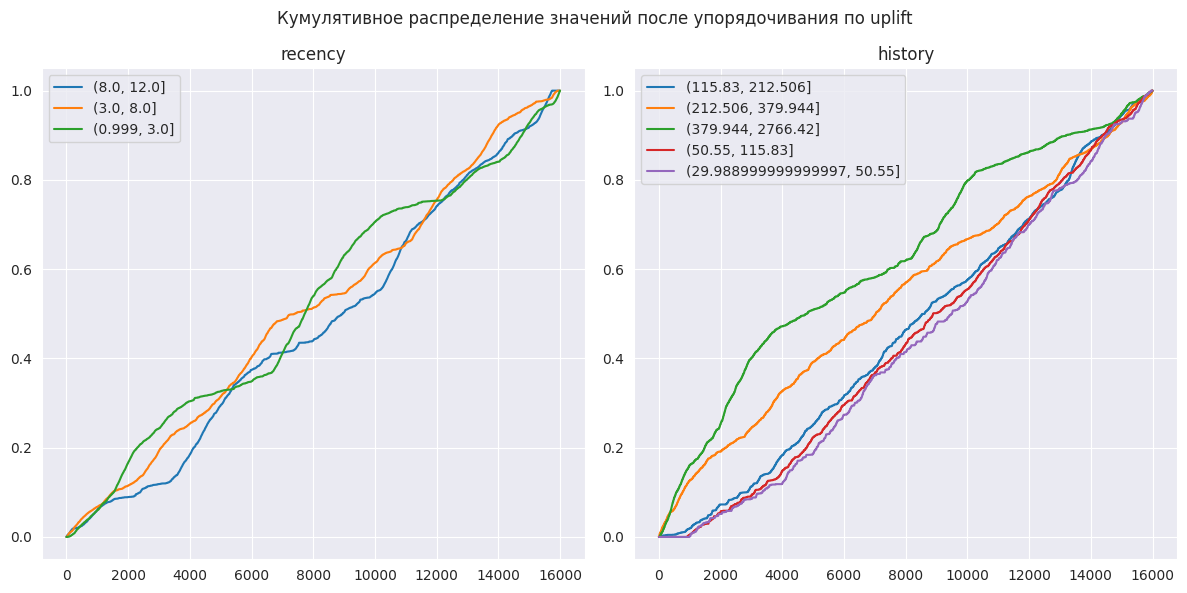

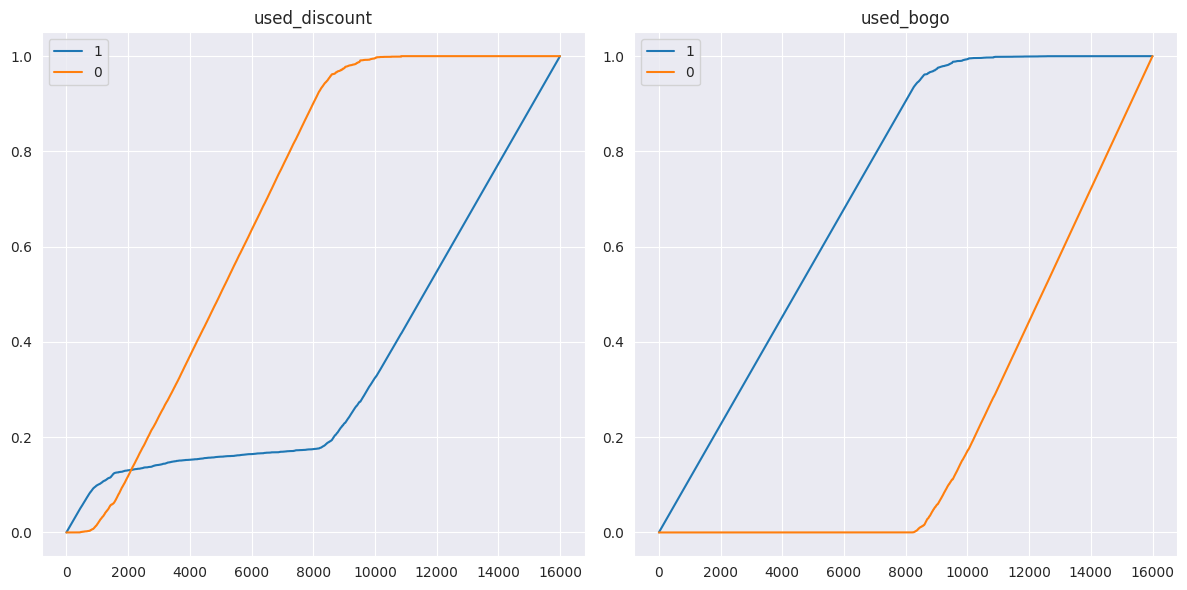

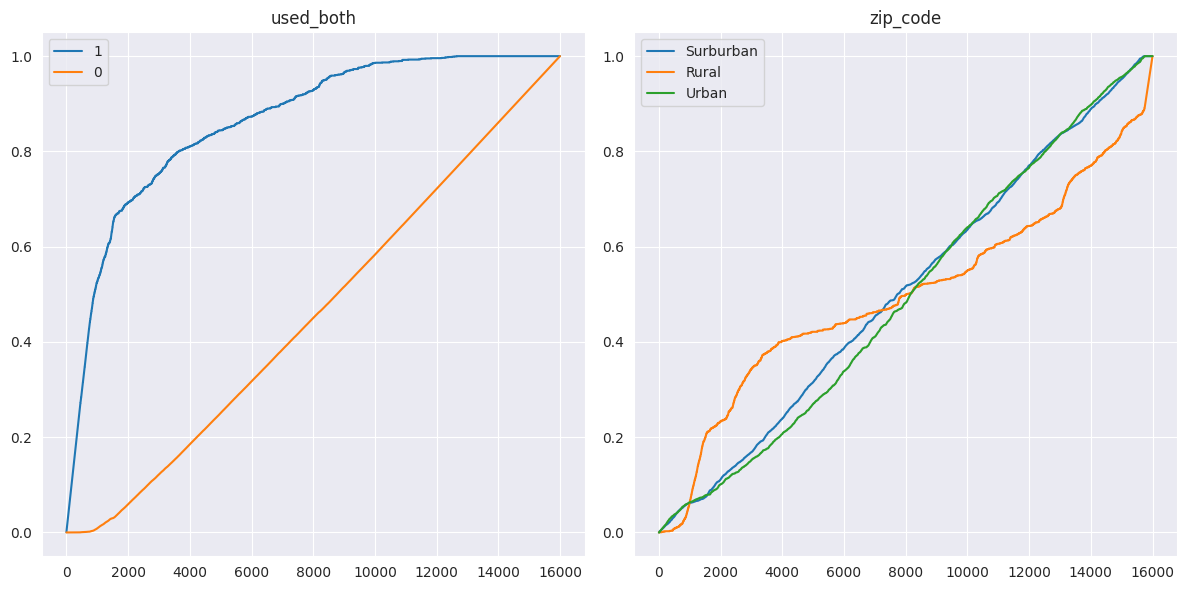

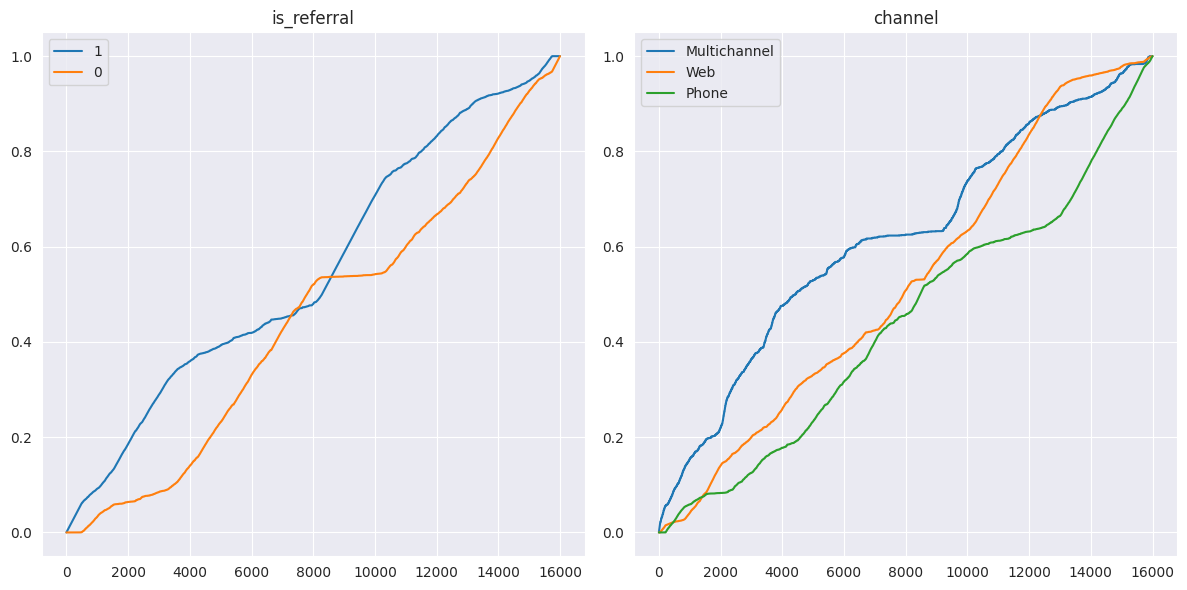

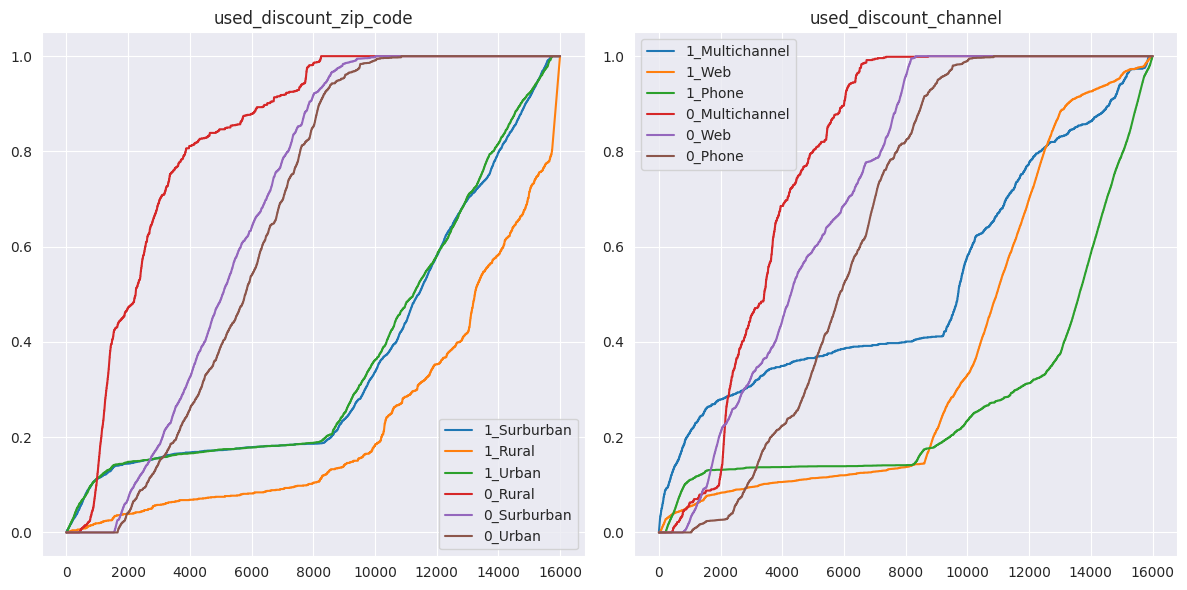

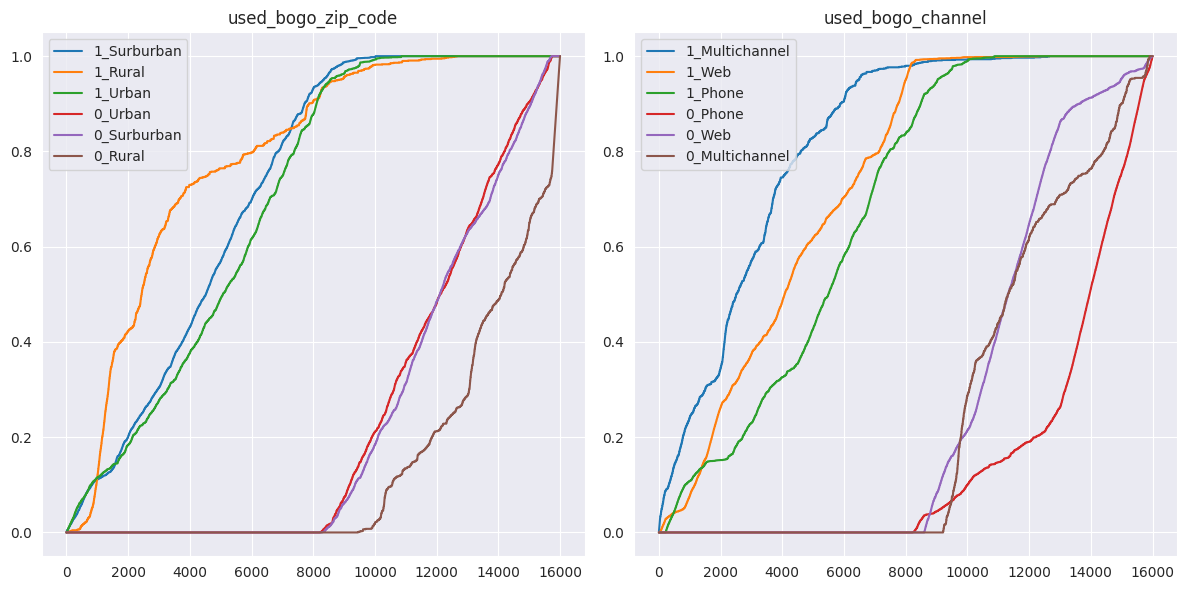

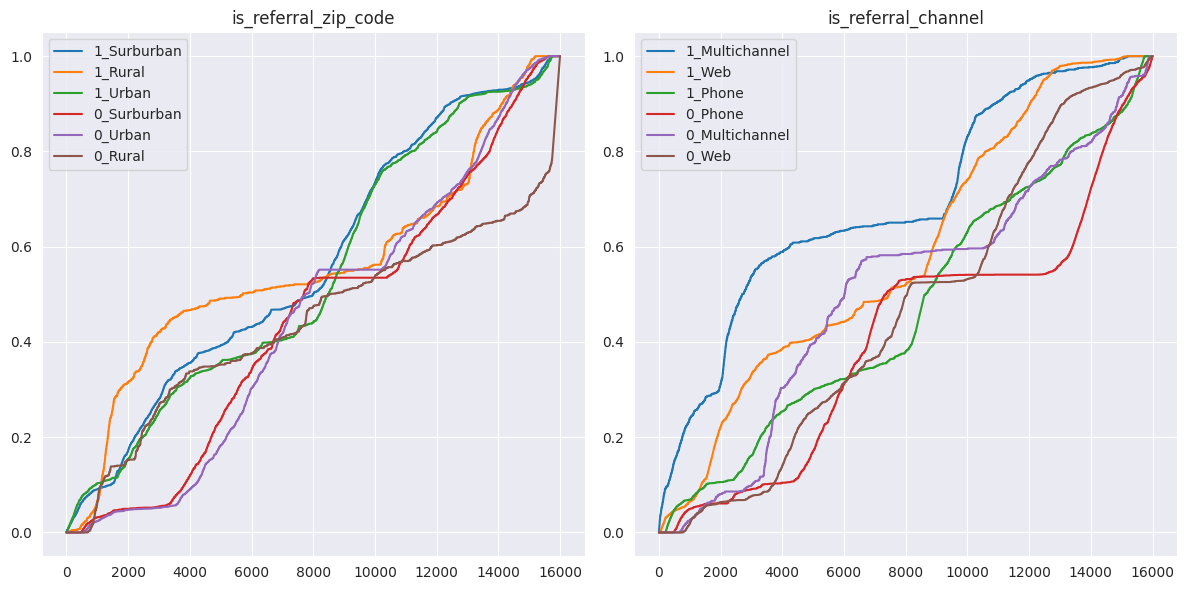

In [62]:
plot_cumulative_effects(df_test, dragonnet_uplift, ncols=[2] * 7, qs={'recency': 3, 'history': 5})

Здесь усреднённый портрет клиента, которому модель собирается предложить оффер, выглядит так:

- Сначала покупал что-то в последний раз более в промежутке между 3 и 8 месяцами назад, а потом сменяется тем клиентом, который покупал что-то недавно не более 3 месяцев назад
- Суммарно потратил много денег (более 379 долларов)
- Поначалу использовал скидку, и постоянно использовал акцию BOGO
- Сначала гороженин и житель пригорода, а потом преимущеcтвенно сельский житель
- В основном нереферальный клиент
- С ним держали связь по обоим каналам связи

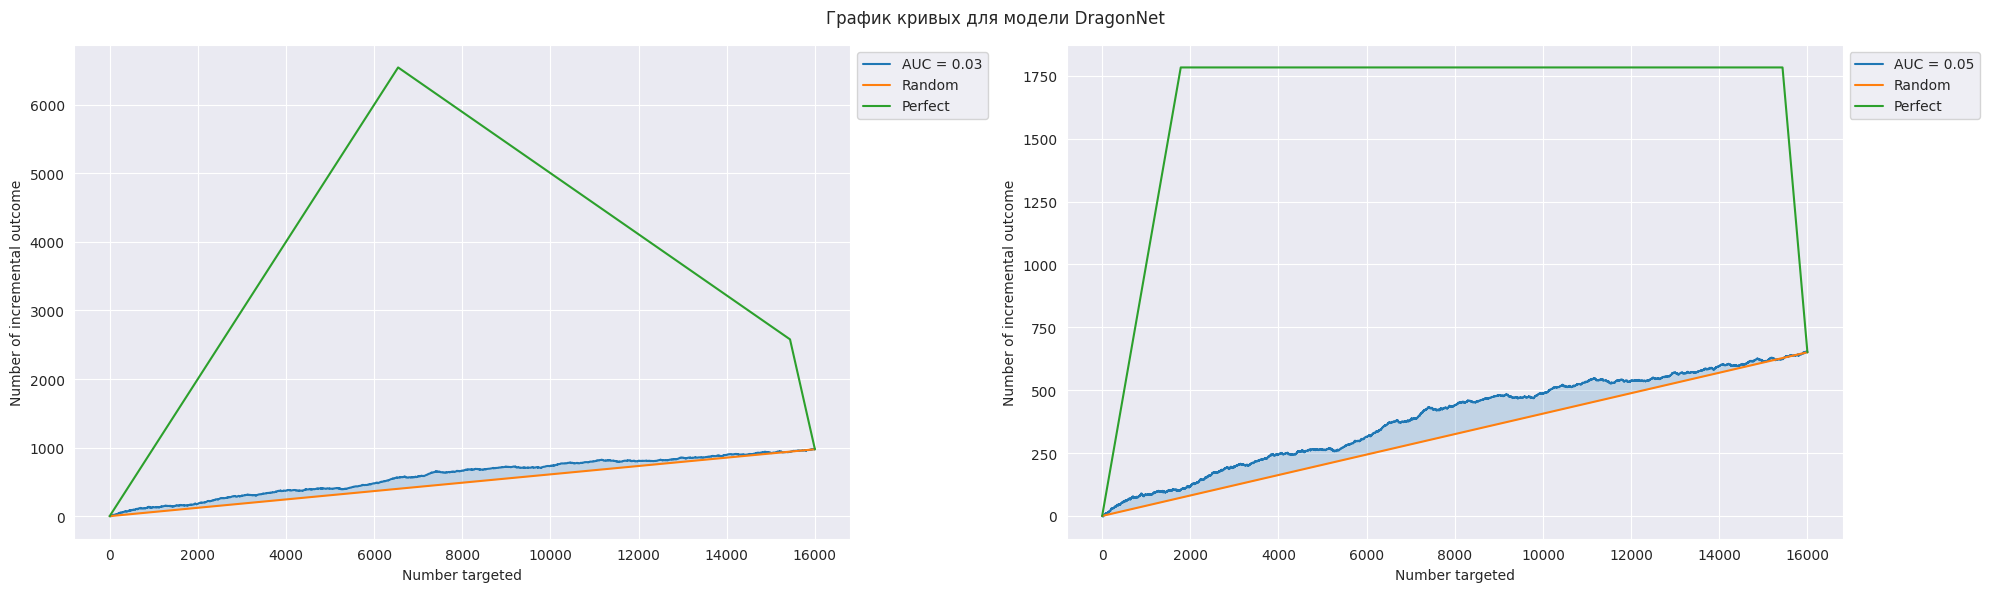

In [56]:
plot_curves(
    y_test,
    dragonnet_uplift,
    treatment_test,
    dragonnet.__class__.__name__
)

Существенного улучшения опять нет

# Выводы

In [57]:
metrics

,uplift@10 (overall),uplift@10 (by group),uplift@30 (overall),uplift@30 (by group),uplift@50 (overall),uplift@50 (by group),Uplift AUC,QINI AUC
CalibratedClassifierCV,0.065305,0.068289,0.078811,0.079177,0.068942,0.067643,0.011007,0.017817
TARNet,0.105221,0.103692,0.088866,0.086837,0.085361,0.085770,0.028250,0.047416
CFRNet,0.087980,0.086790,0.087845,0.086213,0.083415,0.083712,0.029361,0.049224
DragonNet,0.100594,0.098010,0.084035,0.084333,0.082836,0.082578,0.027553,0.045975


Видим, что:
- По метрикам uplift наилучшей оказалась модель TARNet
- А вот по "ранжирующим" метрикам лучше всего себя показала CFRNet
- В целом нейросети в данной задаче справились лучше, чем модель CatBoost
- В финальную верию ноутбука не вошли модели из библиотеки sklift (SoloModel, TwoModels, ClassTransformationReg), но там качество было примерно в 2 раза хуже нейросетевого
- Добавение новых признаков ухудшило качество модели CatBoost, но улучшило качество нейросетевых моделей